# Machine Learning Project - Supervised Learning

## Detailed Description of the MLB Statcast Postseason Pitch-by-Pitch Dataset

### Dataset Summary and Context
This dataset contains detailed pitch-by-pitch records from MLB postseason games. Each row represents a single pitch and includes physical measurements of the pitch, game context, batter/pitcher characteristics, ball tracking information, and situational attributes relevant to decision-making.

The main objective is to predict the type of pitch thrown (**pitch_type**) using supervised machine learning techniques.

* **Primary Source:** MLB Statcast tracking system
* **Data Type:** Mixed numerical and categorical variables
* **Instances:** 14,096 pitches
* **Attributes:** 95 total variables
* **Typical Uses:** Pitch classification, biomechanics analysis, performance analytics, sports data modeling



### Variable Dictionary
Variables are grouped logically according to their role in the game.

#### 1. Game and Player Information
General descriptors that identify the game, the pitcher, and the batter.

* **game_year:** Year in which the game took place.
* **game_date:** Full date of the game.
* **player_name:** Name of the pitcher.
* **pitcher:** Unique MLB identifier for the pitcher.
* **batter:** Unique MLB identifier for the batter.

#### 2. Count, Inning, and At-Bat Context
Variables describing the state of the plate appearance when the pitch was thrown.

* **balls:** Number of balls before the pitch.
* **strikes:** Number of strikes before the pitch.
* **inning:** Current inning number.
* **inning_topbot:** Indicates whether the pitch occurred in the top or bottom half of the inning.
* **at_bat_number:** Turn number of the batter in the game.
* **pitch_number:** Pitch number within the current at-bat.

#### 3. Pitch Result and Event Descriptions
Information about what happened with or after the pitch.

* **events:** Final event outcome (e.g., hit, strikeout, walk, out).
* **description:** Statcast pitch description (called strike, swinging strike, ball, foul).
* **zone:** Strike zone region (1–14) where the pitch crossed.

#### 4. Target Variable (Pitch Identity)
Your classification label.

* **pitch_type:** Abbreviated pitch type (FF, SL, CU, CH, SI…).
* **pitch_name:** Full pitch type name (Fastball, Slider, Curveball…).

#### 5. Pitch Release Metrics
Measurements describing how and where the pitcher released the ball.

* **release_speed:** Speed of the ball at release (mph).
* **release_pos_x:** Horizontal release position from the catcher’s perspective.
* **release_pos_y:** Distance along the mound-to-plate axis at release.
* **release_pos_z:** Height of release point above the ground.
* **release_extension:** Extension of the pitcher’s arm at release (in feet).

#### 6. Pitch Movement and Kinematics
Biomechanical and aerodynamic variables describing the pitch's trajectory.

* **vx0, vy0, vz0:** Initial velocity components in the x, y, and z directions.
* **ax, ay, az:** Accelerations acting on the ball in each axis (movement from spin + drag).
* **pfx_x:** Horizontal break (movement relative to gravity-only path).
* **pfx_z:** Vertical break of the pitch.
* **spin_rate_deprecated:** Ball spin rate (rpm); older Statcast metric format.
* **spin_axis:** Spin axis angle (0–360°), determines break direction.

#### 7. Plate Crossing Location
Where the ball crossed home plate.

* **plate_x:** Horizontal plate-crossing position.
* **plate_z:** Vertical plate-crossing position.

#### 8. Batter–Pitcher Matchup Characteristics
Characteristics of both players that influence pitch selection.

* **stand:** Batter’s stance (L or R).
* **p_throws:** Pitcher’s throwing hand (L or R).

#### 9. Strike Zone Personalization
Definitions of the hitter’s strike zone based on their height.


* **sz_top:** Top boundary of the personalized strike zone.
* **sz_bot:** Bottom boundary of the personalized strike zone.

#### 10. Batted Ball Information
Only present when contact occurs (otherwise empty).

* **launch_speed:** Exit velocity after contact.
* **launch_angle:** Launch angle of the batted ball.
* **hc_x, hc_y:** Hit coordinates projected on the field.
* **hit_distance_sc:** Estimated distance of the hit.
* **launch_speed_angle:** Combined quality-of-contact metric.

#### 11. Base Runners and Game State
Describes the base configuration and scoreboard situation.

* **on_1b, on_2b, on_3b:** IDs of runners on each base (if any).
* **home_score / away_score:** Team scores before the pitch.
* **bat_score / fld_score:** Offensive vs. defensive team scores.
* **post_home_score / post_away_score:** Scores after the event.
* **post_bat_score / post_fld_score:** Post-event offensive/defensive scores.
* **delta_home_win_exp:** Change in win probability for the home team.
* **delta_run_exp:** Change in expected runs.

#### 12.  Defensive Alignments and Umpire
Tactical positioning and officiating.

* **if_fielding_alignment:** Infield alignment (standard, shift, etc.).
* **of_fielding_alignment:** Outfield alignment.
* **fielder_2 / fielder_2.1:** Catcher identifiers.
* **umpire:** Identifier for the home-plate umpire.

#### 13.  Additional Tracking & Deprecated Metadata
System tracking identifiers and legacy fields.

* **sv_id:** Tracking system identifier.
* **tfs_deprecated:** Deprecated time-based ID.
* **tfs_zulu_deprecated:** Deprecated UTC-based tracking ID.

#### 14.  Swing Metrics
Meta-information describing bat movement.

* **bat_speed:** Bat speed at contact point.
* **swing_length:** Length of the swing path.



### Target Variable: `pitch_type`
This column defines the type of pitch thrown. This is the label you will predict using supervised classification methods.

| Code | Meaning |
| :---: | :--- |
| **FF** | Four-Seam Fastball |
| **SL** | Slider |
| **CU** | Curveball |
| **CH** | Changeup |
| **SI** | Sinker |
| **FC** | Cutter |
| **KC** | Knuckle-curve |


## Feature Selection

From the 95 columns available in the original dataset, we have selected a specific subset of **29 predictor variables**. This selection prioritizes physical pitch metrics (kinematics) and strategic game context, while discarding variables that would cause *data leakage* (future information, such as hit results) or irrelevant identifiers.The ones selected are:
- **Balls**: number of balls accumulated in the batter’s count before the pitch. Integer values between 0 and 3.
- **Strikes**: number of strikes accumulated in the count before the pitch. Values between 0 and 2.
- **Outs_when_up**: outs that were recorded in the inning at the moment the pitch was thrown. Values in {0, 1, 2}.
- **On_1b**: identifier of the runner present on first base (if any). It is a categorical variable indicating the presence of a runner; it can be replaced by a binary variable (0 = no runner, 1 = runner present).
- **On_2b**: identifies whether there is a runner on second base. Same interpretation as on_1b.
- **On_3b**: identifies whether there is a runner on third base. Same interpretation as on_1b.
- **Zone**: numerical zone (1–14) where Statcast records that the pitch crossed the catcher’s area. Each number represents a fixed position in the strike-zone plane.
- **Plate_x**: horizontal coordinate of the pitch as it crosses home plate, in feet. Negative values indicate the catcher’s left-hand side (from the catcher’s perspective).
- **Plate_z**: height of the pitch as it crosses home plate, in feet.
- **Pfx_x**: horizontal deviation of the pitch due to spin effects, measured in inches.
- **Pfx_z**: vertical deviation of the pitch relative to its theoretical trajectory without Magnus effect, also in inches.
- **Release_speed**: speed of the pitch at the exact moment it leaves the pitcher’s hand, measured in miles per hour (mph).
- **Effective_speed**: perceived velocity of the pitch by the batter, taking into account arm extension and flight time; also in mph.
- **Release_pos_x**: horizontal position of the pitcher’s hand at release, measured from the catcher’s viewpoint.
- **Release_pos_y**: distance from the mound toward home plate at the moment of release, in feet.
- **Release_pos_z**: exact height at which the pitcher releases the ball, in feet.
- **Vx0**: initial lateral velocity component of the pitch along the X-axis, in feet/second.
- **Vy0**: initial velocity component toward home plate, in feet/second (negative because it moves toward the catcher).
- **Vz0**: initial vertical velocity component, in feet/second.
- **Ax**: horizontal acceleration due to aerodynamic forces and spin effects, in feet/second².
- **Ay**: acceleration toward home plate (usually positive), in feet/second².
- **Az**: vertical acceleration of the pitch (controls drop or rise), in feet/second².
- **Release_spin_rate**: spin rate of the ball, measured in revolutions per minute (rpm).
- **Spin_axis**: orientation of the ball’s spin axis, measured in degrees (0–360).
- **Release_extension**: distance by which the pitcher “moves closer” to home before releasing the ball; in feet.
- **P_throws**: pitcher’s throwing hand (L or R).
- **Stand**: batter’s stance (L or R).
- **Sz_bot**: bottom boundary of the personalized strike zone.
- **Sz_top**: top boundary of the personalized strike zone.



## Neccesary libraries

We load all libraries we need

In [63]:
import pandas as pd 
from sklearn import preprocessing
from sklearn import neighbors
from sklearn.model_selection import train_test_split, GridSearchCV
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score 
from sklearn.svm import SVC
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import export_text




# Data loading

In first place, we load the dataset and we keep the columns that we consider that are going to be neccesary for the model because many of them are irrelevant tsuch as the ID of the pitcher or the ID of the  batter. After selecting the neccesary features features, we take a sample of the full dataset so we can work more efficiently so we will make a plot of the original target variable  to verify that the distribution is maintained.

In [64]:
# Load the dataset
dt = pd.read_csv('Data_MLB_2025_StatcastPostseason_PitchByPitch_20251102a.csv')

#Make a copy of the dataset so we don´t alter the original one
mlb_df = dt.copy()

# Make a list with the names of the columns we will use 
cols = ['balls','strikes','pitch_type','release_speed','release_pos_x','release_pos_z','zone','stand',
        'p_throws','pfx_x','pfx_z','plate_x','plate_z','on_3b','on_2b','on_1b','outs_when_up','vx0',
        'vy0','vz0','ax','ay','az','sz_top','sz_bot','effective_speed','release_spin_rate','release_extension',
        'release_pos_y','spin_axis']

# Select the columns that we will use 
mlb_df = mlb_df[cols]

# Print the number of columns and observations
print('The number of columns is',len(mlb_df.columns))
print('The number of observations is',len(mlb_df))

# Check the distribution of the target variable 
orig = mlb_df['pitch_type'].value_counts(normalize=True)


The number of columns is 30
The number of observations is 14096


Now we will plot the distribution of the target variable in the original dataset

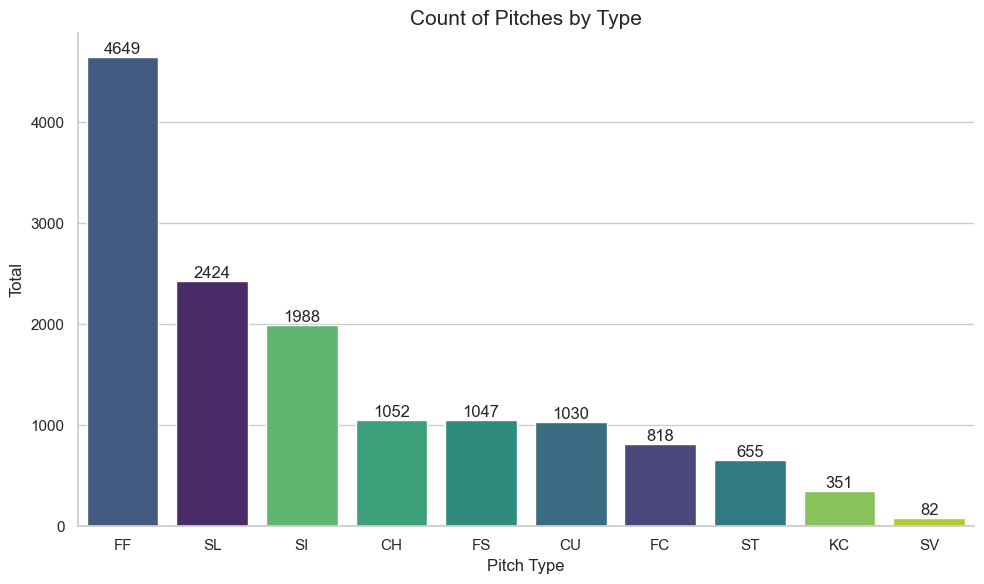

In [65]:
#Establish the size of the figure
fig, ax = plt.subplots(figsize=(10, 6))

ax = sns.countplot(  data=mlb_df,   x='pitch_type', 
    order=mlb_df['pitch_type'].value_counts().index,  palette='viridis',legend=False,hue='pitch_type') 

ax.set_title("Count of Pitches by Type", fontsize=15)
ax.set_xlabel("Pitch Type")
ax.set_ylabel("Total")

# Give value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container)

#Aesthetic adjustments
sns.despine()
plt.tight_layout()

# Show the plot
plt.show()


<p style="text-align: center;"><em>Figure 1:  original pitch_type distribution</em></p>


Once we have made this, is time to create the sample of the data. We have decided to create a sample of 5000 observations, but this can be changed if it is neccesary

In [66]:
# Create a sample of 5000 observations to work more effectiently
mlb_df= mlb_df.sample(n=5000, random_state=42)

#Check the length of the new dataset
print('The number of observations in the sample is', len(mlb_df))



The number of observations in the sample is 5000


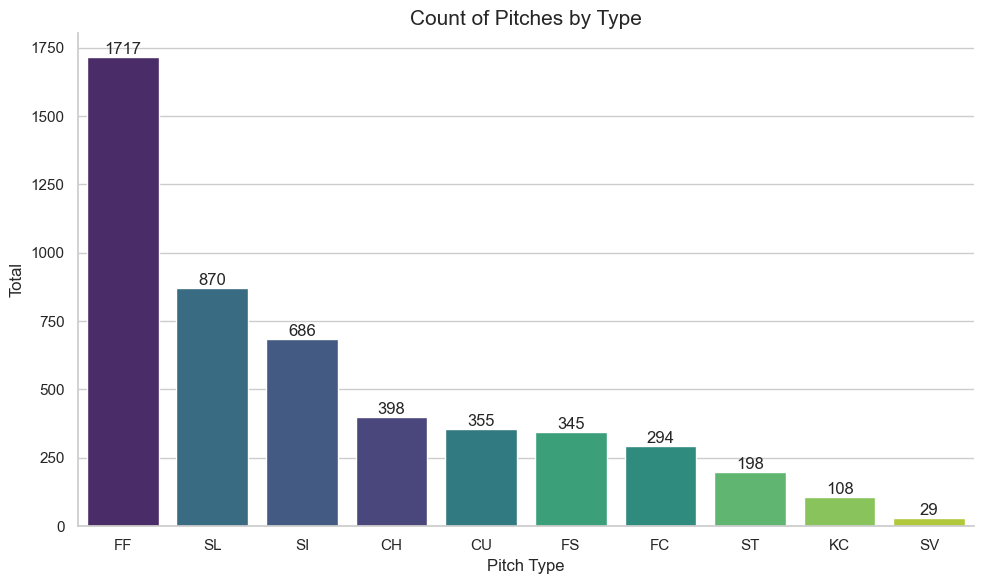

In [67]:
#Establish the size of the figure
plt.figure(figsize=(10, 6))


ax = sns.countplot(  data=mlb_df,   x='pitch_type', 
    order=mlb_df['pitch_type'].value_counts().index,  palette='viridis',legend=False,hue='pitch_type')

ax.set_title("Count of Pitches by Type", fontsize=15)
ax.set_xlabel("Pitch Type")
ax.set_ylabel("Total")

# Give value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container)

#Aesthetic adjustments
sns.despine()
plt.tight_layout()

# Show the plot
plt.show()

<p style="text-align: center;"><em>Figure 2:  sample  pitch_type distribution</em></p>


At first sight, the distribution of the sample is similar to the original one, so we could say that this sample should not cause any issues. However, to be more confident about this, we can perform an additional comparison.

We will use pandas to check whether each variable has the same proportion of occurrences.

In [68]:
#Check the distribution of the target variable in the sample
sample = mlb_df['pitch_type'].value_counts(normalize=True)

# We compare the original distribution with the sample distribution
compare = pd.concat([orig, sample], axis=1, keys=['original', 'sample'])
print(compare)

            original  sample
pitch_type                  
FF          0.329810  0.3434
SL          0.171964  0.1740
SI          0.141033  0.1372
CH          0.074631  0.0796
FS          0.074276  0.0690
CU          0.073070  0.0710
FC          0.058031  0.0588
ST          0.046467  0.0396
KC          0.024901  0.0216
SV          0.005817  0.0058


Based on this, we can be fully confident that the proportions are preserved.

Once we have performed the initial steps, we are going to focus on the task. First of all, we are going to show the dataframe

In [69]:
#Show the dataframe
mlb_df.head(10)

,balls,strikes,pitch_type,release_speed,release_pos_x,release_pos_z,zone,stand,p_throws,pfx_x,...,ax,ay,az,sz_top,sz_bot,effective_speed,release_spin_rate,release_extension,release_pos_y,spin_axis
7013,0,0,FF,92.0,-1.48,6.15,11,L,R,-0.60,...,-8.136912,30.972294,-13.376455,3.19,1.50,92.3,2360.0,6.6,53.88,210.0
903,0,1,CH,86.3,2.22,6.42,14,R,L,1.08,...,12.504362,24.629326,-24.148714,2.99,1.38,87.1,1668.0,6.8,53.71,132.0
6997,0,0,SI,91.7,2.28,5.64,14,R,L,1.41,...,17.941591,33.141481,-32.406414,3.48,1.69,90.9,1962.0,6.2,54.28,136.0
1586,0,2,FF,92.8,-0.56,6.10,11,L,R,-0.78,...,-10.014090,27.714042,-14.601183,3.27,1.50,93.0,2119.0,6.2,54.30,217.0
455,0,0,SL,90.8,-2.03,6.19,6,R,R,0.51,...,4.872652,25.820373,-29.161962,3.42,1.69,91.5,2400.0,6.5,54.01,131.0
6956,1,1,SL,80.4,2.27,5.70,7,L,L,-0.55,...,-4.260414,20.219494,-27.789891,3.70,1.79,80.6,2303.0,6.2,54.34,273.0
2021,0,2,CU,87.5,-0.96,5.97,14,R,R,0.20,...,1.519850,29.307363,-41.503735,4.15,1.84,88.0,2767.0,6.9,53.59,14.0
13970,1,1,CH,84.8,-1.00,5.42,14,L,R,-1.22,...,-13.556683,23.806895,-29.110887,3.74,1.76,85.3,1167.0,6.6,53.94,266.0
168,1,2,FF,98.0,2.35,6.15,1,R,L,0.30,...,5.927218,32.620994,-13.788273,3.49,1.62,98.8,2487.0,6.8,53.71,141.0
169,0,0,FF,96.8,2.25,6.19,1,L,L,0.15,...,3.955557,32.610507,-15.468507,3.67,1.87,98.0,2400.0,7.1,53.41,150.0


With the first ten instances, we can see that some features are numerical while others are categorical, so we will need to preprocess the data later.

After this step, we want to have a preliminary understanding of the features’ ranges and standard deviations. We make this with the function 'describe'.

In [70]:
# Get a summary of the dataset
mlb_df.describe(include='all')

,balls,strikes,pitch_type,release_speed,release_pos_x,release_pos_z,zone,stand,p_throws,pfx_x,...,ax,ay,az,sz_top,sz_bot,effective_speed,release_spin_rate,release_extension,release_pos_y,spin_axis
count,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000,5000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,4999.000000,4996.000000,5000.000000,5000.000000,4996.000000
unique,NaN,NaN,10,NaN,NaN,NaN,NaN,2,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,FF,NaN,NaN,NaN,NaN,R,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1717,NaN,NaN,NaN,NaN,2684,3597,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.880000,0.912400,NaN,90.839320,-0.830580,5.778824,8.993600,NaN,NaN,-0.135248,...,-2.520432,29.207563,-23.620348,3.402864,1.599002,91.027245,2279.337670,6.522200,53.978000,177.087870
std,0.979486,0.829496,NaN,5.906732,1.895909,0.494863,4.282012,NaN,NaN,0.871125,...,11.028958,4.188290,9.529243,0.192609,0.105454,6.010245,398.887345,0.474426,0.472603,73.462374
min,0.000000,0.000000,NaN,69.200000,-4.310000,2.750000,1.000000,NaN,NaN,-1.940000,...,-25.768943,17.138446,-48.973696,2.600000,1.200000,68.900000,427.000000,5.100000,52.440000,0.000000
25%,0.000000,0.000000,NaN,86.400000,-2.210000,5.460000,5.000000,NaN,NaN,-0.850000,...,-11.524146,25.895323,-30.552377,3.260000,1.520000,86.650000,2170.000000,6.300000,53.720000,133.000000
50%,1.000000,1.000000,NaN,91.900000,-1.610000,5.730000,11.000000,NaN,NaN,-0.240000,...,-2.909354,29.162704,-23.801789,3.390000,1.590000,92.000000,2355.000000,6.500000,53.970000,201.000000
75%,2.000000,2.000000,NaN,95.700000,0.830000,6.070000,13.000000,NaN,NaN,0.540000,...,5.676941,32.549379,-14.606625,3.530000,1.670000,95.850000,2509.000000,6.800000,54.240000,222.000000


Although the description is not crucial for this task, we can highlight two aspects:

1. There are features with fewer than 5,000 instances, meaning that there are null values in the dataset.

2. We can observe features that have higher weights than others (by looking at the “std” row)

3. The ranges connfirm meaningful differences between features.

As we said in the first point, we think we have missing values so before training any model we have to check this 

In [71]:
# Check for missing values
nulos = mlb_df.isna().sum()
nulos[nulos > 0]


on_3b                4575
on_2b                4096
on_1b                3416
effective_speed         1
release_spin_rate       4
spin_axis               4
dtype: int64

Seeing this, we can confirm our suspicions, so we need to treat the missing values. For the features with only a small number of missing entries, we decided to drop those rows, since this action will not significantly affect the models. However, the features ‘on_1b’, ‘on_2b’, and ‘on_3b’ contain many missing values. After investigating, we found that the rows with values include an ID related to a player, meaning that these three features provide information about whether a player is on a given base. For this reason, we decided to convert their values to 1 (player on the base) and 0 (no player on the base) and keep them, since we believe that knowing how many players are on base is very useful for predicting the pitch type.

In [72]:
#Create new binary features indicating the presence of runners on bases
#When there is a runner on base, the value is 1, otherwise it is 0
mlb_df['has_runner_1b'] = mlb_df['on_1b'].notna().astype(int)
mlb_df['has_runner_2b'] = mlb_df['on_2b'].notna().astype(int)
mlb_df['has_runner_3b'] = mlb_df['on_3b'].notna().astype(int)

#Drop the original columns indicating the runners on bases
mlb_df = mlb_df.drop(columns=['on_1b', 'on_2b', 'on_3b'])

#Drop rows with missing values (the other ones that are few)
mlb_df=mlb_df.dropna()

#Check for missing values again
nulos = mlb_df.isna().sum()
nulos[nulos > 0]


Series([], dtype: int64)

We successfully eliminated missing values

In [73]:
#Check the length of the dataset after dropping missing values
len(mlb_df)

4995

As we said before, droping few rows  have not affected because we have almost the same number of instances. Moving to the new three features , we are a bit curious about them, so we will try to examine the situations that occur in each instance (whether there is a player on the base or not).

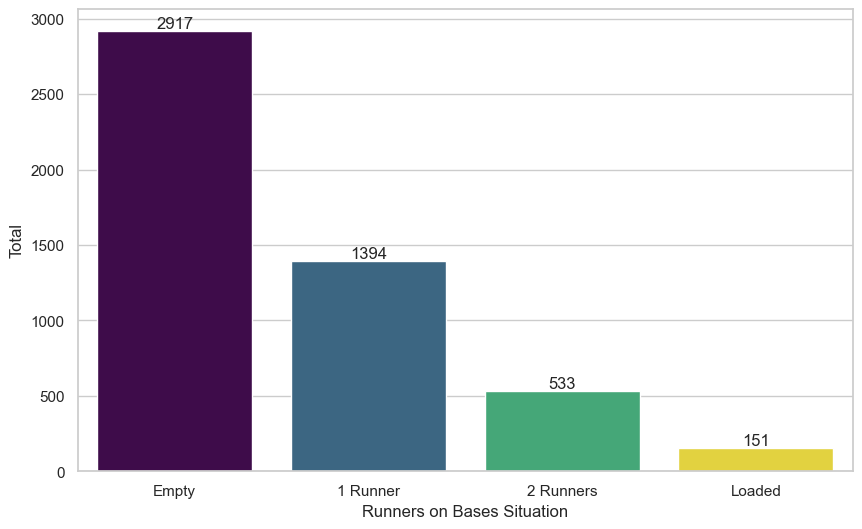

In [74]:
# Calculate the situation of runners on bases 
count_runners = mlb_df[['has_runner_1b', 'has_runner_2b', 'has_runner_3b']].sum(axis=1)

#Count the occurrences of each situation
result = count_runners.value_counts().sort_index()

#Establish the size of the figure
plt.figure(figsize=(10, 6))

# Create a bar plot
ax = sns.barplot(x=result.index, y=result.values, palette='viridis',legend=False,hue=result.index)
ax.set_ylabel("Total")
ax.set_xlabel("Runners on Bases Situation")
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['Empty', '1 Runner', '2 Runners', 'Loaded'])
for container in ax.containers:
    ax.bar_label(container)
#Show the plot
plt.show()

<p style="text-align: center;"><em>Figure 3:  Runners on base situation</em></p>


Now this result makes sense, showing us that the raw values are not always what we need to look at.

After dropping missing walues we want to check is there are any null values, which is the same as before, but making a second check is better

In [75]:
# Check for null values
nulos = mlb_df.isnull().sum()
nulos[nulos > 0]


Series([], dtype: int64)

We do not have null values, so  we can continue with our project

In [76]:
# Show the data types of each column
mlb_df.dtypes

balls                  int64
strikes                int64
pitch_type            object
release_speed        float64
release_pos_x        float64
release_pos_z        float64
zone                   int64
stand                 object
p_throws              object
pfx_x                float64
pfx_z                float64
plate_x              float64
plate_z              float64
outs_when_up           int64
vx0                  float64
vy0                  float64
vz0                  float64
ax                   float64
ay                   float64
az                   float64
sz_top               float64
sz_bot               float64
effective_speed      float64
release_spin_rate    float64
release_extension    float64
release_pos_y        float64
spin_axis            float64
has_runner_1b          int64
has_runner_2b          int64
has_runner_3b          int64
dtype: object

As we have seen before, there are numerical and categorical features. We want to examine the distribution of each one to determine whether any features are imbalanced or if it is necessary to drop them. To do this, we decided to plot them.

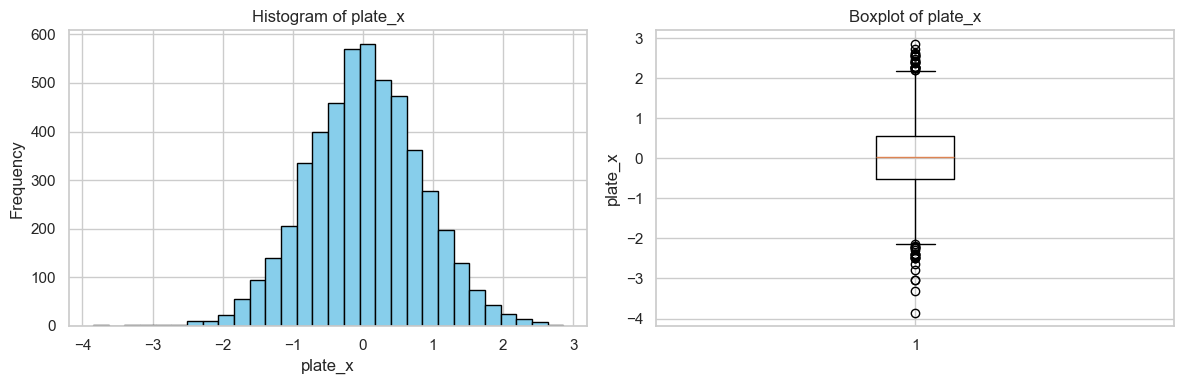

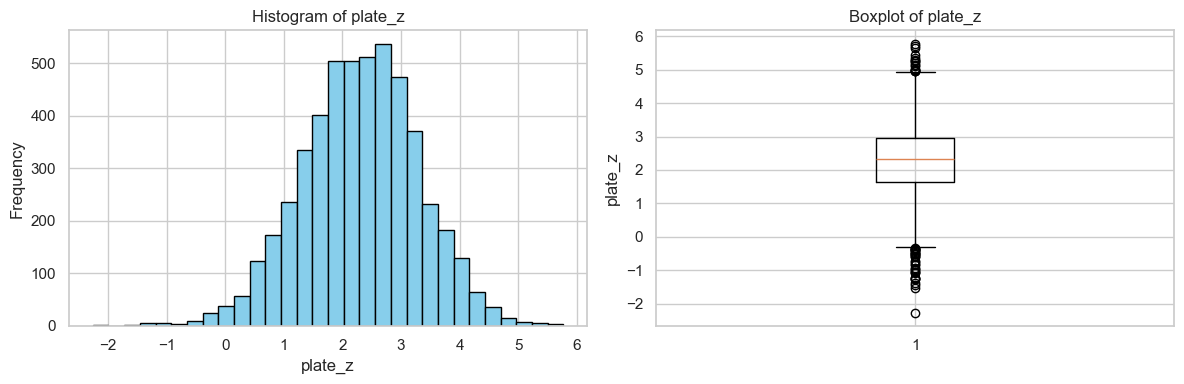

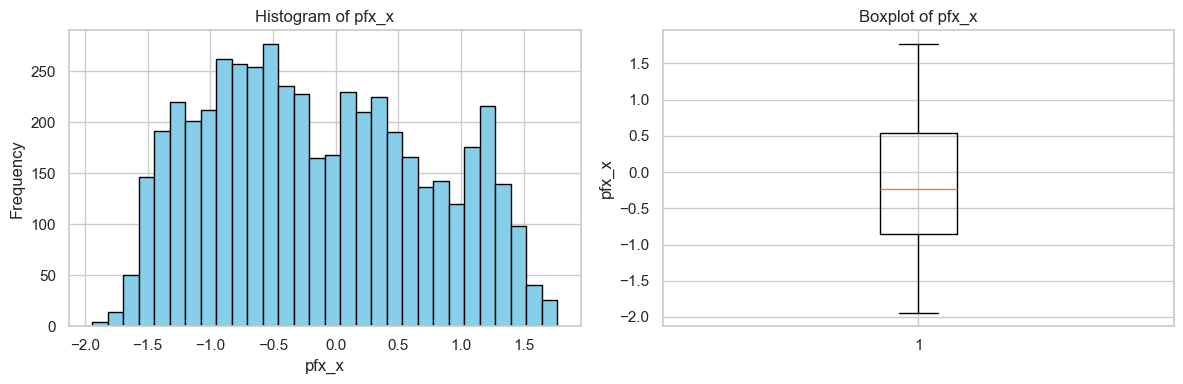

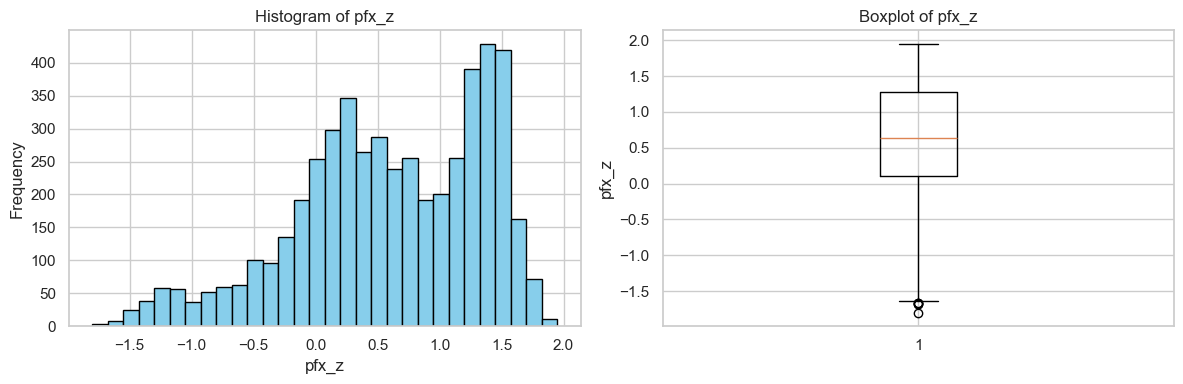

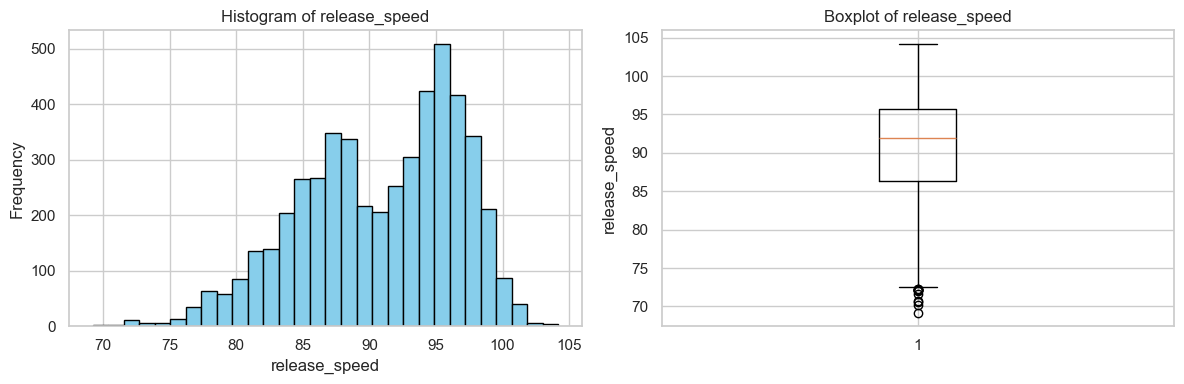

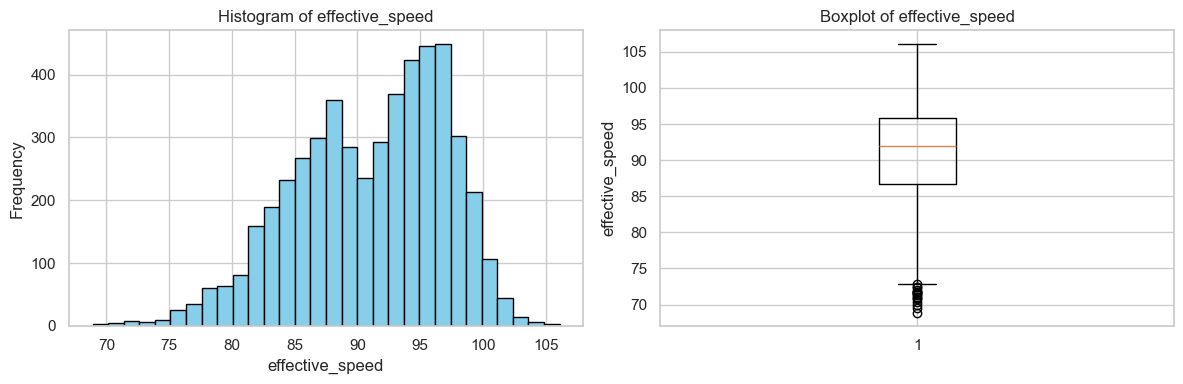

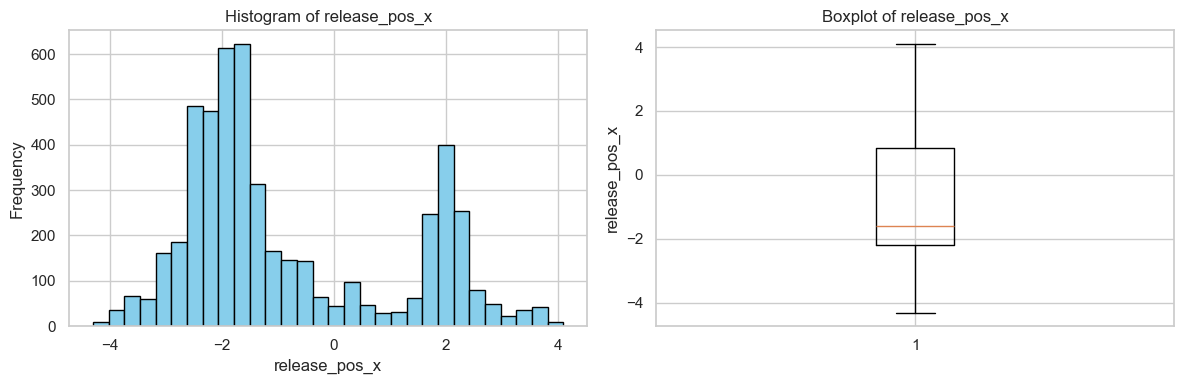

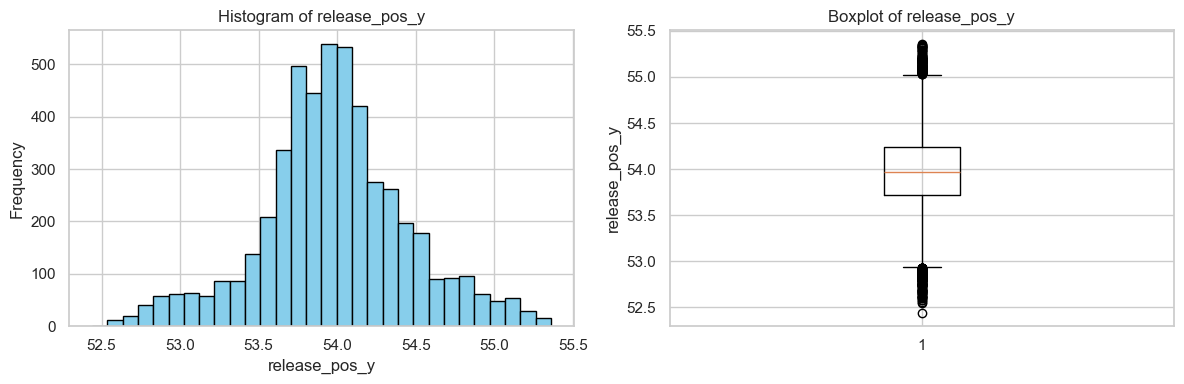

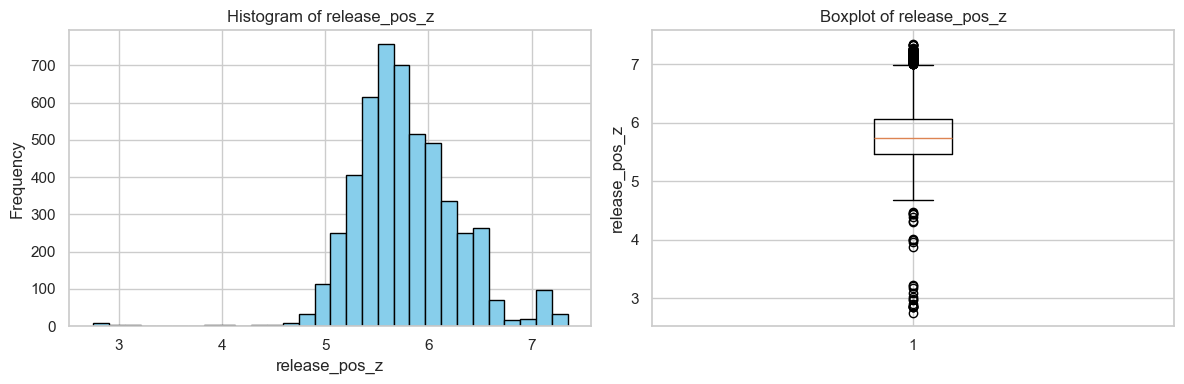

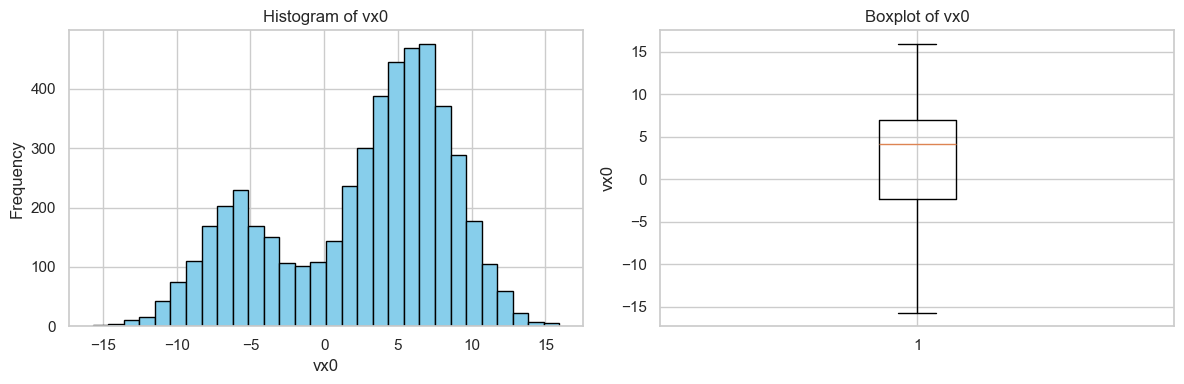

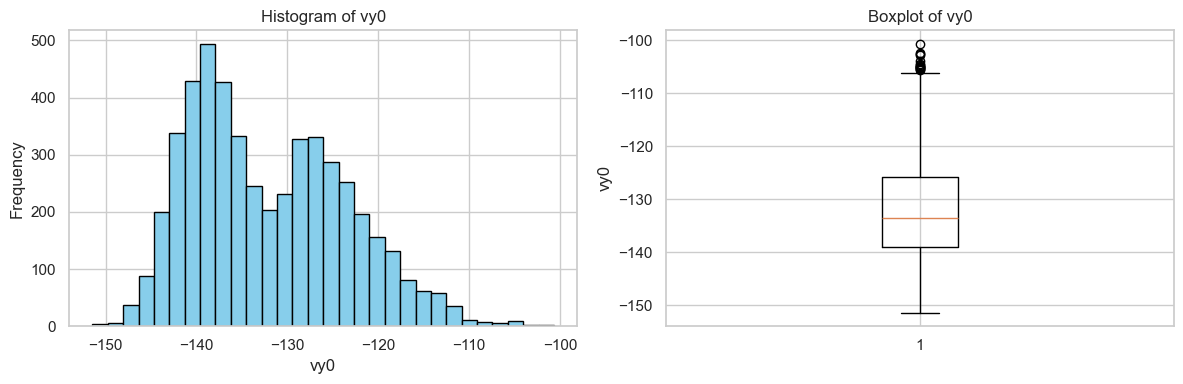

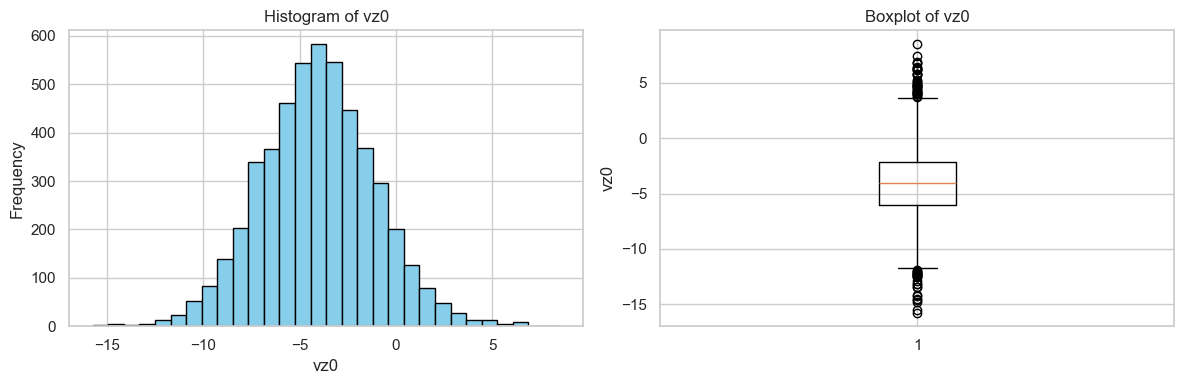

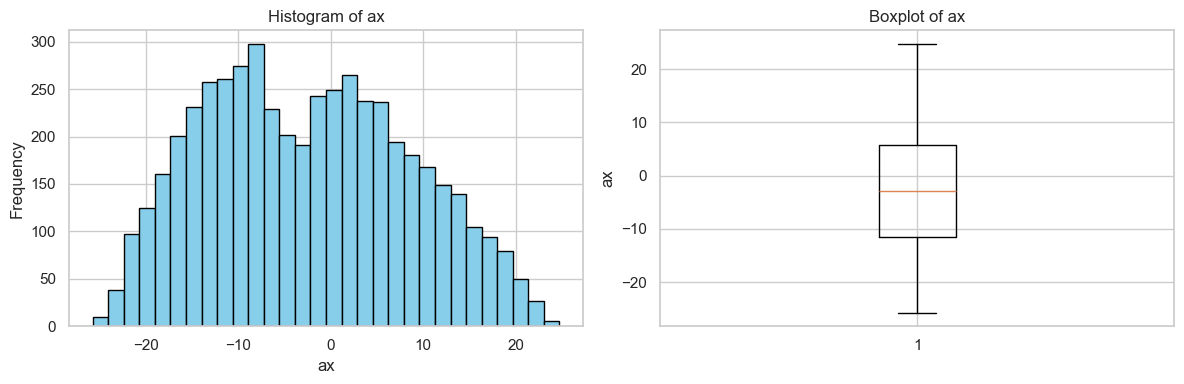

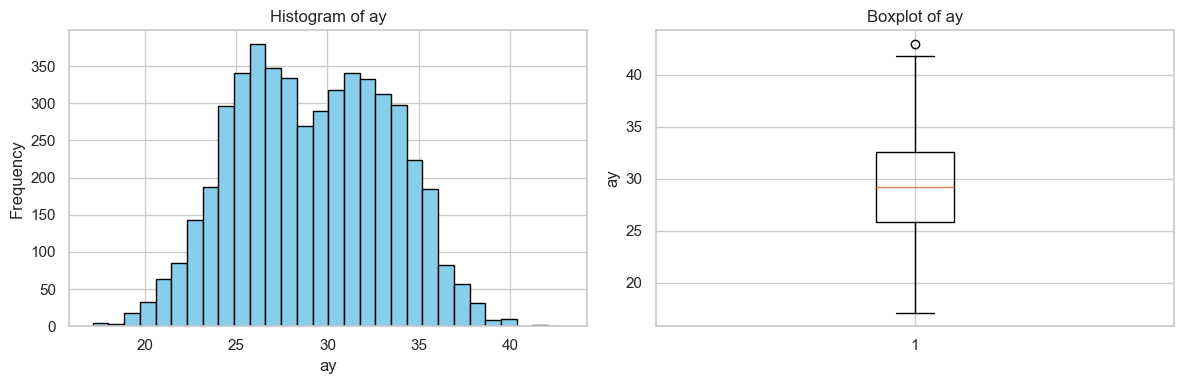

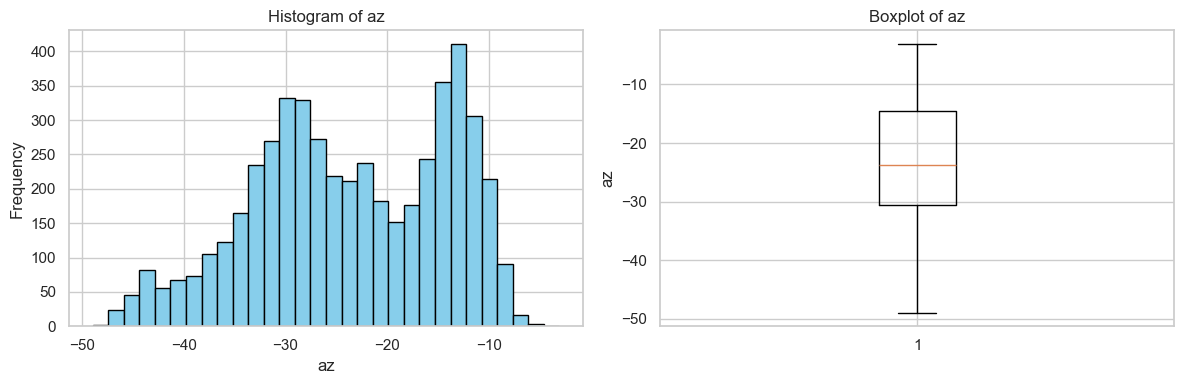

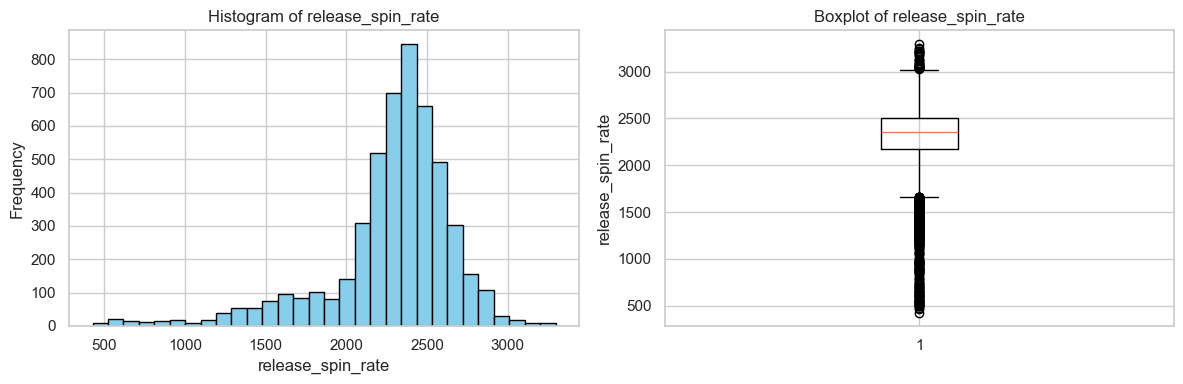

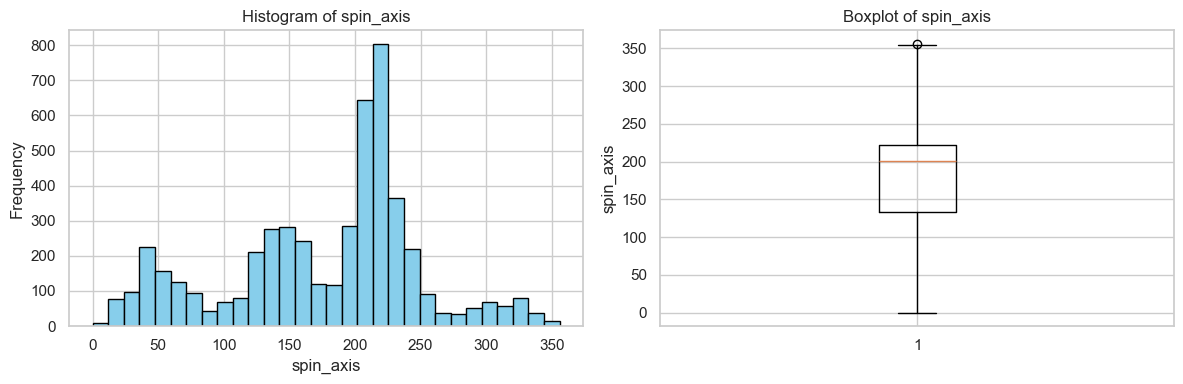

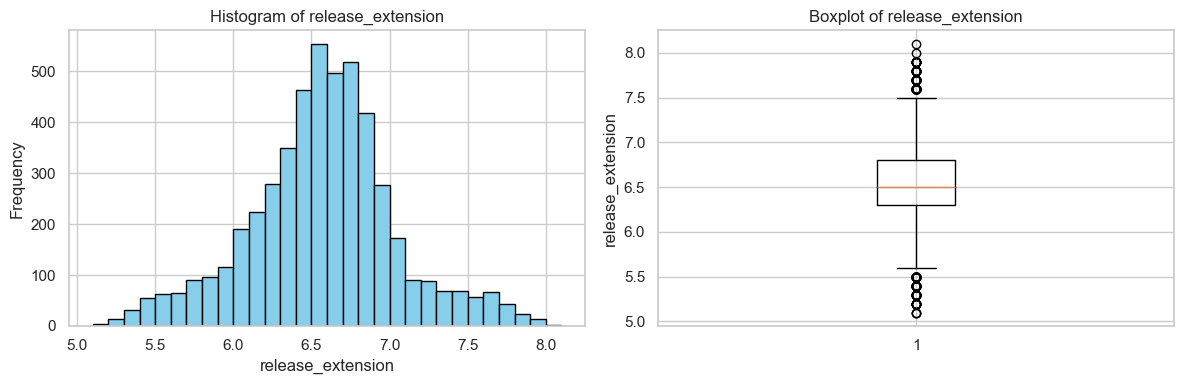

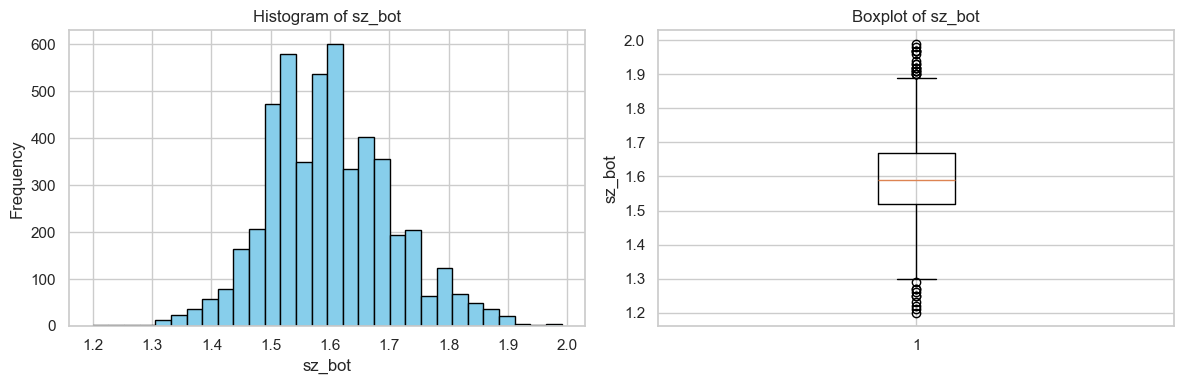

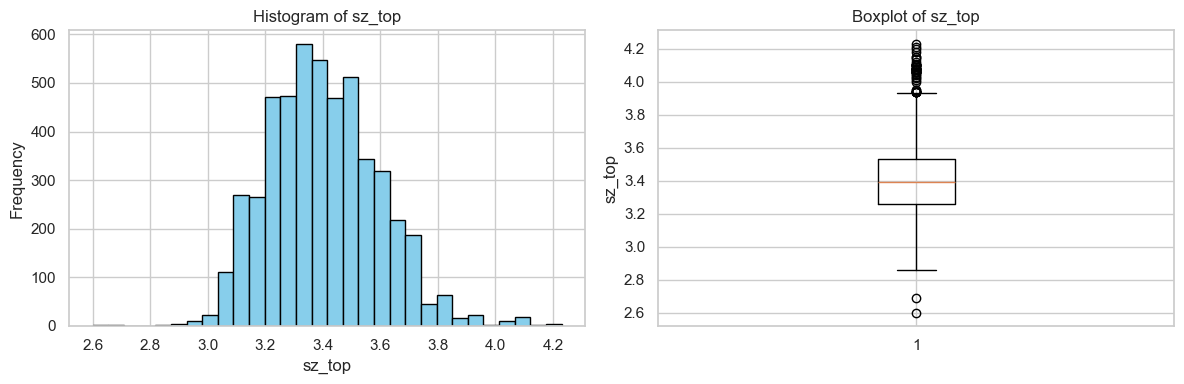

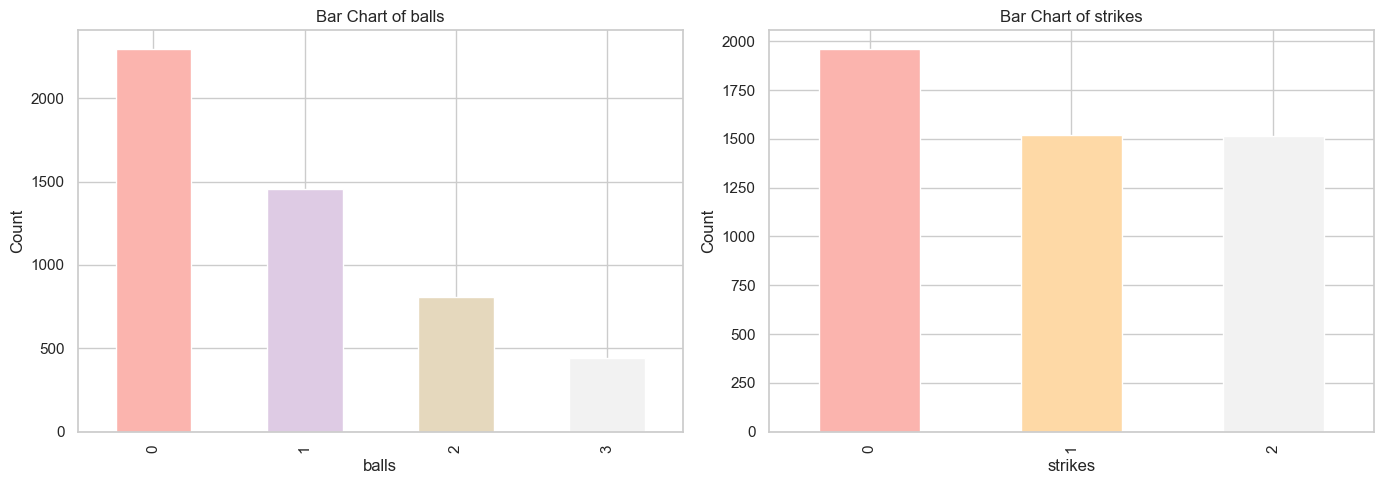

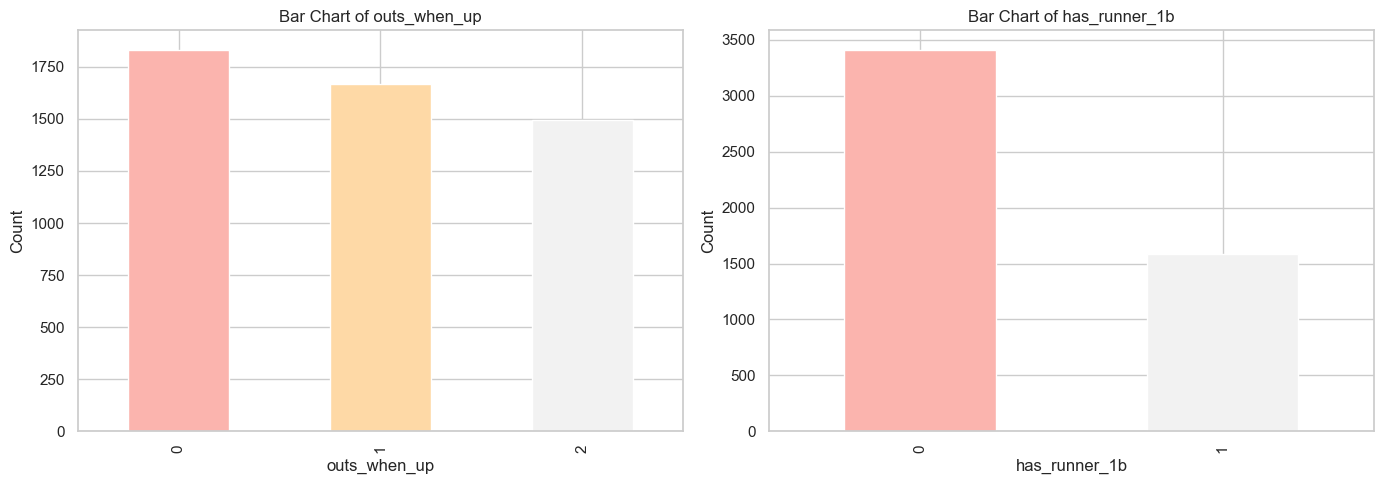

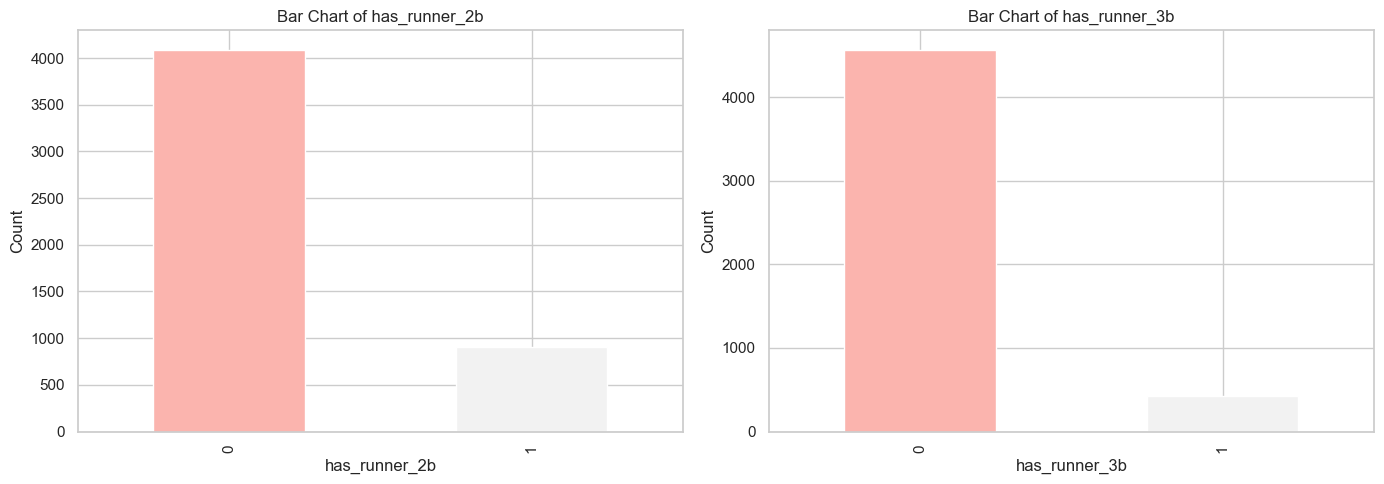

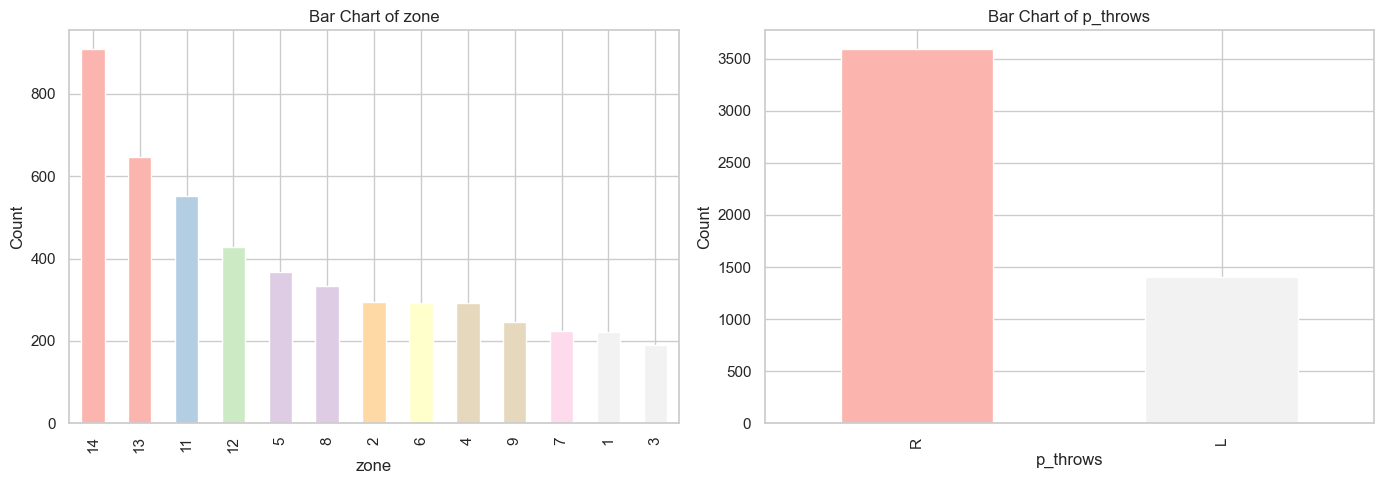

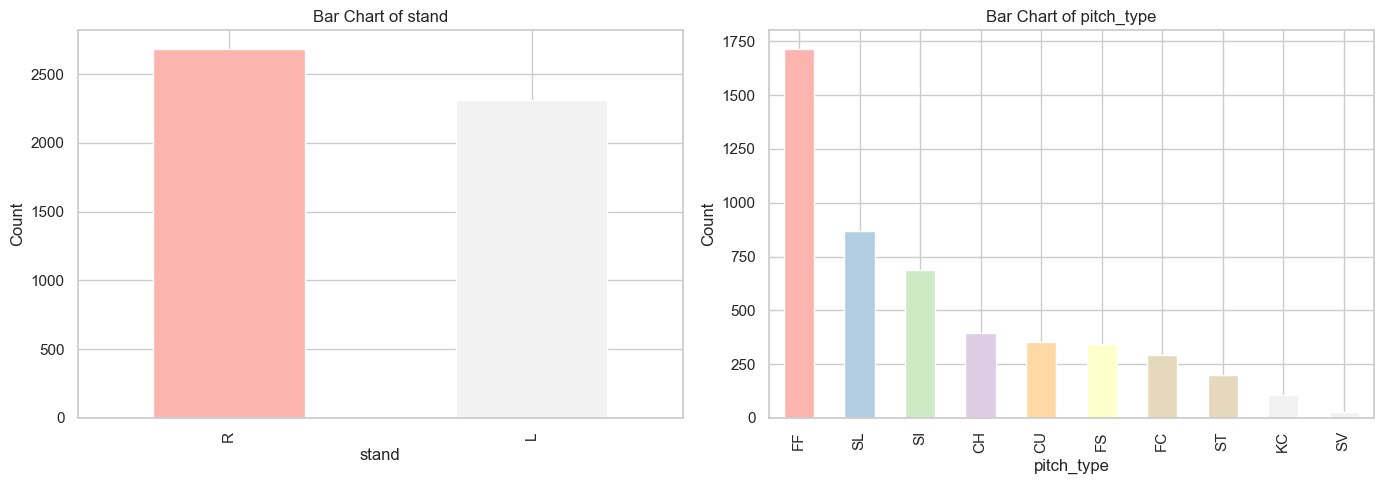

In [77]:
#Select numeric and categorical/discrec columns
numeric_cols = ['plate_x', 'plate_z', 'pfx_x', 'pfx_z', 'release_speed', 'effective_speed',
                 'release_pos_x', 'release_pos_y', 'release_pos_z', 'vx0', 'vy0', 'vz0', 'ax', 
                 'ay', 'az', 'release_spin_rate', 'spin_axis', 'release_extension', 'sz_bot', 'sz_top']

categorical_discrec_cols = ['balls', 'strikes', 'outs_when_up', 'has_runner_1b', 'has_runner_2b',
                             'has_runner_3b', 'zone', 'p_throws','stand','pitch_type']



#Make histograms and boxplot of numeric variables in pairs
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    #Histogram
    axes[0].hist(mlb_df[col], bins=30, linewidth=1, edgecolor='black', color='skyblue')
    axes[0].set_title(f"Histogram of {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")
    axes[0].set


    #Boxplot
    axes[1].boxplot(mlb_df[col], vert=True)
    axes[1].set_title(f"Boxplot of {col}")
    axes[1].set_ylabel(col)

    # Adjust layout and show the plots
    plt.tight_layout()
    plt.show()



#Make barchat of categorical/discrec variables 
for i in range(0, len(categorical_discrec_cols), 2):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cols_batch = categorical_discrec_cols[i:i+2]

    for ax, col in zip(axes, cols_batch):
        cont = mlb_df[col].value_counts()

        #Generate a unique list of colors for this chart
        colors = plt.cm.Pastel1(np.linspace(0, 1, len(cont)))
        
        #Makwe the bar chart
        cont.plot(kind='bar', ax=ax, color=colors)
        ax.set_title(f"Bar Chart of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.tick_params(axis='x', rotation=90)
        
    # Adjust layout and show the plots
    plt.tight_layout()
    plt.show()

<p style="text-align: center;"><em>Figure 4:  features distribution</em></p>


The distribution of the numerical features appears to be normal. It is true that there are outliers and that the distributions are not perfect, but there is nothing unusual.

On the other hand, regarding the categorical features, we have almost balanced distributions, so we do not need to drop any of them. The only feature that is imbalanced is the one indicating whether there is a player on third base, but we have already seen that it is important, so we cannot remove it.

Once we have seen the grahps, we are going to transform the columns 'p_throws' and 'stand' because they are binary but their values are not 1 or 0, instead, they are L (left) and R (right)

In [78]:
# Encode categorical variables
mlb_df['p_throws'] = mlb_df['p_throws'].map({'L': 0, 'R': 1})
mlb_df['stand']    = mlb_df['stand'].map({'L': 0, 'R': 1})

# Show again the dataframe
mlb_df

,balls,strikes,pitch_type,release_speed,release_pos_x,release_pos_z,zone,stand,p_throws,pfx_x,...,sz_top,sz_bot,effective_speed,release_spin_rate,release_extension,release_pos_y,spin_axis,has_runner_1b,has_runner_2b,has_runner_3b
7013,0,0,FF,92.0,-1.48,6.15,11,0,1,-0.60,...,3.19,1.50,92.3,2360.0,6.6,53.88,210.0,0,0,0
903,0,1,CH,86.3,2.22,6.42,14,1,0,1.08,...,2.99,1.38,87.1,1668.0,6.8,53.71,132.0,0,0,0
6997,0,0,SI,91.7,2.28,5.64,14,1,0,1.41,...,3.48,1.69,90.9,1962.0,6.2,54.28,136.0,1,0,0
1586,0,2,FF,92.8,-0.56,6.10,11,0,1,-0.78,...,3.27,1.50,93.0,2119.0,6.2,54.30,217.0,0,0,0
455,0,0,SL,90.8,-2.03,6.19,6,1,1,0.51,...,3.42,1.69,91.5,2400.0,6.5,54.01,131.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8452,1,2,FF,99.6,-1.76,5.11,12,1,1,-0.72,...,3.51,1.64,101.4,2565.0,7.4,53.11,219.0,1,0,0
11814,0,1,FF,92.6,1.84,5.98,11,1,0,0.85,...,3.42,1.59,91.8,2262.0,6.1,54.43,139.0,0,0,0
10046,3,1,SL,84.0,-1.76,5.55,11,0,1,1.09,...,3.27,1.58,84.7,2216.0,6.7,53.85,52.0,0,0,0
132,2,2,FF,98.4,0.25,6.28,6,1,0,0.12,...,3.23,1.48,99.9,2478.0,7.3,53.24,157.0,0,1,0


We have finnished the preprocess step so it is time to create different types of models and analyze them

# Creation and training of models

Before we begin, we split the dataset into training and testing sets. As we mentioned before, the target class will be ‘pitch_type’, so ,firstly, we split the dataset into features and target variable

In [79]:
#Split features and target variable
X_mlb = mlb_df.drop(['pitch_type'], axis=1)
Y_mlb= mlb_df['pitch_type']

Once the data is ready, we can split it into training and testing sets

In [80]:
#Split the dataset into training and testing sets with 80% for training and 20% for testing and random_state=42 
XTrain_mlb, XTest_mlb, yTrain_mlb, yTest_mlb= train_test_split(X_mlb, Y_mlb, test_size= 0.2, random_state= 42)

We have the selected a state because we want to keep  reproducibility. 

To boost our project and make it more professional, we applied something our teacher suggested: instead of scaling the training set once and then using that same scaler to transform the test set, we decided to scale the data inside each cross-validation fold. This approach ensures that the scaler is fitted only on the training portion of each fold, preventing data leakage and giving us a more realistic and reliable evaluation of our models. 

Note: we only want to scale numeric features.

In [81]:
#Define the numeric columns for scaling
numeric_cols = ['plate_x', 'plate_z', 'pfx_x', 'pfx_z', 'release_speed', 'effective_speed',
                'release_pos_x', 'release_pos_y', 'release_pos_z', 'vx0', 'vy0', 'vz0',
                'ax', 'ay', 'az', 'release_spin_rate', 'spin_axis', 'release_extension',
                'sz_bot', 'sz_top', 'balls', 'strikes', 'outs_when_up', 'zone']

#Create the ColumnTransformer that will allow us to scale the numeric columns on
#the training portion of each fold. This will be used later in a Pipeline
preprocess = ColumnTransformer(transformers=[('num', preprocessing.StandardScaler(), numeric_cols)],remainder='passthrough')



We have finished the previous steps. Moving  on to the next stage, we now need to build different type of models which are:
1. KNN
2. SVM
3. Logistic regresion
4. Decision tree

## 1º. KNN

Define the process of finding the best KNN model by trying different parameters (k values and metrics).

In [82]:
#Define the k values to try
k_values= list(range(1, 21))

#Create a pipeline that scales the data and then applies a KNN model
pipe_knn = Pipeline([('preprocess', preprocess), ('knn', neighbors.KNeighborsClassifier())])

#Define a grid that includes the different parameters to be tried
param_grid = {'knn__n_neighbors': k_values,'knn__metric': ['euclidean', 'manhattan']}

#Perform cross-validation to identify the best model and the optimal parameters
grid_knn = GridSearchCV(pipe_knn, param_grid, cv=10, scoring='f1_macro', n_jobs= -1)

#Fit the preivous model with the train data
grid_knn.fit(XTrain_mlb, yTrain_mlb)

#Print the best parameters and the best score
print("Best parameters founded:", grid_knn.best_params_)
print("Best CV punctuation:", grid_knn.best_score_)

#We want to extract the scores of the 10 cross-validations of the best model found
#so we convert the cv resutls to a Dataframe a we select the row corresponding to the best parameters

#Convert the cv resutols to a Dataframe
results = pd.DataFrame(grid_knn.cv_results_)  

#Select the row corresponding to the best model
best_row = results[results["rank_test_score"] == 1].iloc[0]

#There are a lot of columns, but we select only the ones corresponding to the cross-validation scores
cv_scores = best_row[[f"split{i}_test_score" for i in range(10)]]

#Print the  scores
print("Scores of the 10 cross-validations of the best model:")
print(cv_scores.values.astype(float)) #We use astype so when we print it out it only print the numbers

Best parameters founded: {'knn__metric': 'manhattan', 'knn__n_neighbors': 1}
Best CV punctuation: 0.7943325844427431
Scores of the 10 cross-validations of the best model:
[0.76589703 0.83371572 0.75814639 0.80178683 0.80474368 0.74028938
 0.81576793 0.78122655 0.84162134 0.800131  ]


The metric selected for finding the best model is f1_macro, because it takes both false positives and false negatives into account, which makes it more suitable for slightly imbalanced data. The best model achieves an f1_macro score of 0.7943325844427431.

In [83]:
best_knn = grid_knn.best_estimator_
best_knn

,steps,"[('preprocess', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


The best KNN model was obtained with the following parameters:

- n_neighbors: 1
- metric: manhattan

Make a plot to show the f1_macro performance achieved by the different parameter combinations. It will display the evolution of the different metrics for each k value.

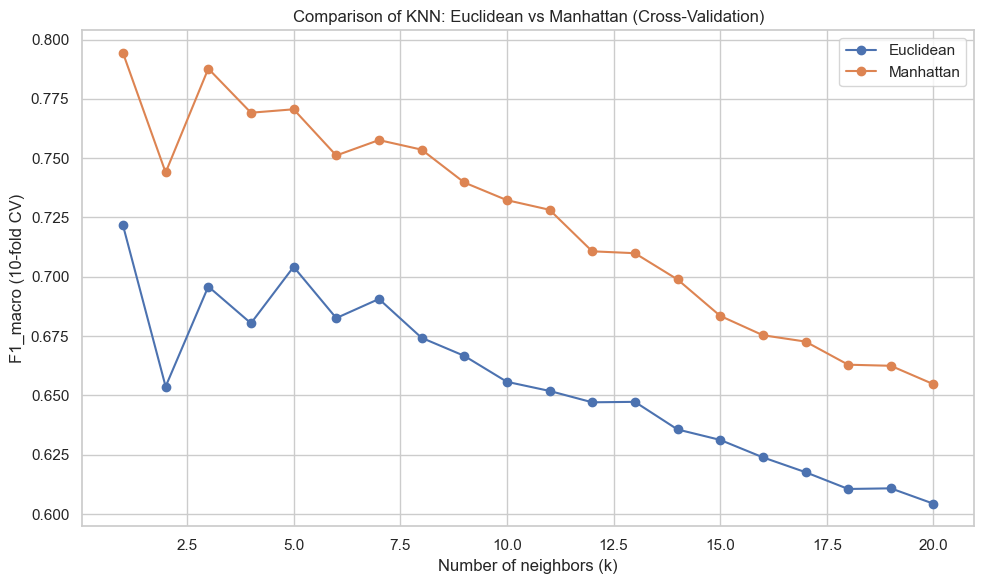

In [84]:
#Convert the results form Croos-Validation into a DataFrame
results = pd.DataFrame(grid_knn.cv_results_)

#Keep only with the results where the metric used is euclidean and sort them by k
eucl = results[results['param_knn__metric'] == 'euclidean'].sort_values('param_knn__n_neighbors')
#Keep only with the results where the metric used is Manhattan and sort them by k
manh = results[results['param_knn__metric'] == 'manhattan'].sort_values('param_knn__n_neighbors')

#Take the mean f1_macro for euclidean metric
f1_euclidean = eucl['mean_test_score'].values
#Take the mean f1_macro for Manhattan metric
f1_manhattan = manh['mean_test_score'].values

plt.figure(figsize=(10,6))
#Plot the f1_macro for the different k's and euclidean metric
plt.plot(k_values, f1_euclidean, marker='o', label='Euclidean')
#Plot the f1_macro for the different k's and Manhattan metric
plt.plot(k_values, f1_manhattan, marker='o', label='Manhattan')


# Add the legend, title and text in the axis in the plot
plt.xlabel('Number of neighbors (k)')
plt.ylabel('F1_macro (10-fold CV)')
plt.title('Comparison of KNN: Euclidean vs Manhattan (Cross-Validation)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

<p style="text-align: center;"><em>Figure 5: Comparison of KNN: Euclidean vs Manhattan (Cross-Validation)</em></p>


In the previous figure, we can see that the Manhattan distance performs better than the Euclidean distance. Another observation is that the best value of k is k = 1. This figure shows the F1-macro scores used by the cross-validation procedure to select the best model

## 2º. SVM

Now, the different hyperparameters to be tested for this model are defined.

In [85]:
#Define a pipeline with goal of preprocess the data (scale the numerical columns) and use a SVM model
pipe_svm = Pipeline([('preprocess', preprocess), ('svm', SVC(random_state=42))])

#Create a grid with the hyperparameters to try, with the penalties (C), kernel and gamma for the non-linear kernel, class_weight 
param_grid_svm = {'svm__C': [0.1, 1, 10, 100], 'svm__kernel': ['linear', 'rbf'], 'svm__gamma': ['scale', 'auto'], 
                  'svm__class_weight': [None, 'balanced']}

#Apply GridSearchCV for making Cross-Validation, with the preivous grid, 10 fold and optimizing by the f1 macro
grid_svm = GridSearchCV(estimator=pipe_svm, param_grid=param_grid_svm, cv=10, scoring='f1_macro', n_jobs=-1)
#Fit the Cross-Validation in the train data
grid_svm.fit(XTrain_mlb, yTrain_mlb)

#Print the best parameters and the best score
print("Best parameters founded:", grid_svm.best_params_)
print("Best CV punctuation:", grid_svm.best_score_)

#We want to extract the scores of the 10 cross-validations of the best model found
#so we convert the cv resutls to a Dataframe a we select the row corresponding to the best parameters

#Convert the cv resutols to a Dataframe
results = pd.DataFrame(grid_svm.cv_results_)  

#Select the row corresponding to the best model
best_row = results[results["rank_test_score"] == 1].iloc[0]

#There are a lot of columns, but we select only the ones corresponding to the cross-validation scores
cv_scores = best_row[[f"split{i}_test_score" for i in range(10)]]

#Print the  scores
print("Scores of the 10 cross-validations of the best model:")
print(cv_scores.values.astype(float)) #We use astype so when we print it out it only print the numbers

Best parameters founded: {'svm__C': 10, 'svm__class_weight': None, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV punctuation: 0.8142678133356759
Scores of the 10 cross-validations of the best model:
[0.84191728 0.81617296 0.82524189 0.8037066  0.79910937 0.80129655
 0.7480474  0.81059664 0.82769028 0.86889916]


The obtained macro f1-score corresponds to the best SVM model identified through hyperparameter.

In [86]:
best_svm = grid_svm.best_estimator_
best_svm

,steps,"[('preprocess', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In the SVC section, the hyperparameters used to produce the best model are shown:

- The chosen value C = 10 represents a medium-to-high regularization strength, providing a balance between closely fitting the training data and maintaining enough regularization to generalize well.
- The selected kernel is RBF, a non-linear kernel that enables the model to capture more complex decision boundaries than a linear one.
- The gamma parameter is set to 'scale', meaning its value is automatically determined from the variance of the data, adapting the model’s flexibility to the input features.
- The class_weight parameter is set to None, so no additional weighting is applied to compensate for class imbalance.


Plot the evolution of the hyperparameters and show the bets combination of the best SVM model

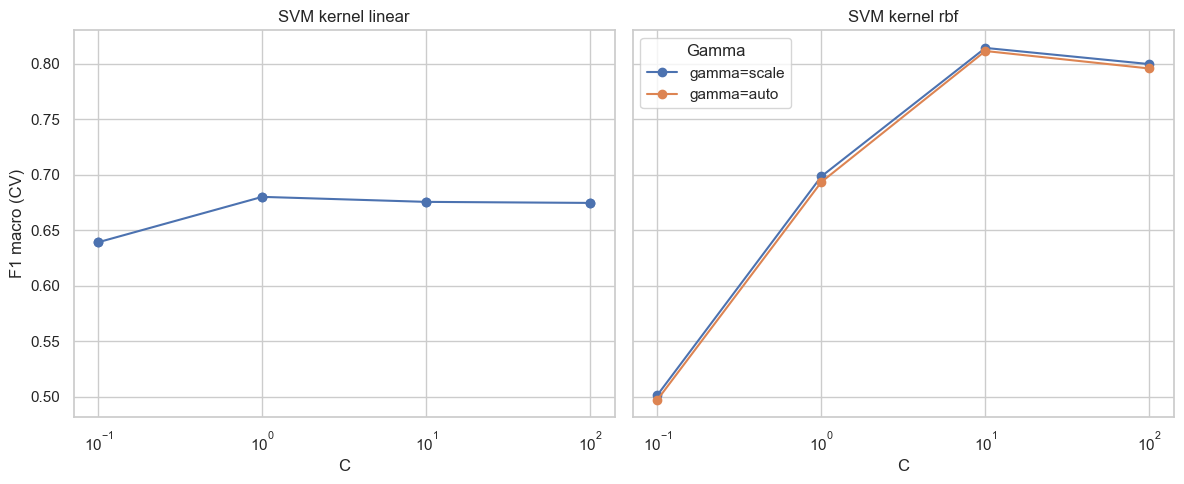

In [87]:
#Convert the cross-validation results from Cross-Validation into a DataFrame
results = pd.DataFrame(grid_svm.cv_results_)

#Add the C values as floats to sort them properly
results['C'] = results['param_svm__C'].astype(float)

#Create a subplot to compare the performance for linear and RBF kernels
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

ax = axes[0]
kernel = 'linear'
#Select the results for the linear kernel and plot how f1 changes with C
mask_linear = ((results['param_svm__kernel'] == kernel) & (results['param_svm__class_weight'].isna()))

linear_df = results[mask_linear].sort_values('C')

ax.plot(linear_df['C'], linear_df['mean_test_score'], marker='o')
ax.set_xscale('log')
ax.set_xlabel('C')
ax.set_ylabel('F1 macro (CV)')
ax.set_title('SVM kernel linear')
ax.grid(True)

#Select the results for the RBF kernel and plot how f1 changes with C and the different gamma
ax = axes[1]
kernel = 'rbf'

for gamma_value in ['scale', 'auto']:
    mask_rbf = ((results['param_svm__kernel'] == kernel) & (results['param_svm__gamma'] == gamma_value) & 
                (results['param_svm__class_weight'].isna()))

    rbf_df = results[mask_rbf].sort_values('C')

    ax.plot(rbf_df['C'], rbf_df['mean_test_score'], marker='o', label=f'gamma={gamma_value}')

ax.set_xscale('log')
ax.set_xlabel('C')
ax.set_title('SVM kernel rbf')
ax.grid(True)
ax.legend(title='Gamma')

plt.tight_layout()
plt.show()



<p style="text-align: center;"><em>Figure 6:  Evaluation of hyperparameters</em></p>


## 3.º Logistic Regresion

Now is turn to the the Logistic Regresion, which its main objective is to predict the probability that an observation belongs to a specific category. Firstly, we will look for the best parameters using the GridSearching, optimizing for f1_macro and employing 10 folds.

In [88]:
#Create the pipeline with preprocessing and logistic regression with max_iter=5000 so 
# the grid search can converge
pipe_lg=Pipeline([('preprocess', preprocess), ('logreg', LogisticRegression(max_iter=5000))])

#Fist of all, we define the parameter grid of the logistic regression to be checked with cross-validation
param_grid = {

    "logreg__C": [0.001, 0.01, 0.1, 1, 10,50,100,300,1000], #Values of C to test
    "logreg__penalty": ["l2"], #Use only l2 penalty
    "logreg__solver": ["lbfgs", "newton-cg"], #Solvers that support multinomial option
    "logreg__class_weight": [None, "balanced"] #Class weight options to see if it is necessary to handle class imbalance
}


#Create the GridSearchCV object from the logistic regression model and the parameter grid
# with 10-fold cross-validation, scoring by f1_macro and n_jobs=-1 to use all processors so 
# the grid search can be faster
grid_rl=GridSearchCV(estimator=pipe_lg,param_grid=param_grid,cv=10,scoring='f1_macro',n_jobs=-1)

# Fit the GridSearchCV object on the training set to find the best hyperparameters
grid_rl.fit(XTrain_mlb,yTrain_mlb)


#Print the best parameters and the best score
print("Best parameters founded:", grid_rl.best_params_)
print("Best CV punctuation:", grid_rl.best_score_)


#We want to extract the scores of the 10 cross-validations of the best model found
#so we convert the cv resutls to a Dataframe a we select the row corresponding to the best parameters

#Convert the cv resutols to a Dataframe
results = pd.DataFrame(grid_rl.cv_results_)  

#Select the row corresponding to the best model
best_row = results[results["rank_test_score"] == 1].iloc[0]

#There are a lot of columns, but we select only the ones corresponding to the cross-validation scores
cv_scores = best_row[[f"split{i}_test_score" for i in range(10)]]

#Print the  scores
print("Scores of the 10 cross-validations of the best model:")
print(cv_scores.values.astype(float)) #We use astype so when we print it out it only print the numbers



Best parameters founded: {'logreg__C': 300, 'logreg__class_weight': None, 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs'}
Best CV punctuation: 0.6744162757864846
Scores of the 10 cross-validations of the best model:
[0.73830107 0.64705479 0.68177742 0.63298229 0.69413669 0.69476781
 0.70119573 0.68186073 0.63539524 0.63669098]


We have printed three things:

1. Best parameters founded: in our case the best combination of parameters that achieved the highest average performance during cross-validation  are C=300, penalty='l2', solver = 'lbfgs' and class_weight='None'. 

2. Best CV punctuation: the best model  achieve an average f1-macro score of 0.674.

3. Scores of the 10 cross-validations of the best model:  the range of the individual fold scores goes from 0.63 to 0.74. This shows that the model performs well overall but there is a moderate variability, which is common in multiclass classification problems .



Once we had the best model, we save it.

In [89]:
#Save the best logistic regression model
best_rl=grid_rl.best_estimator_

#Show the best logistic regression model
best_rl


,steps,"[('preprocess', ...), ('logreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


We have the best model, so now the next step is to analyse some graphs and metrics. We are going to start with the importance of each feature which in logistic regresion is determined  by the magnitude of its coefficients (weights). Features with larger absolute coefficients have a greater influence on the model’s predictions.

(10, 29)


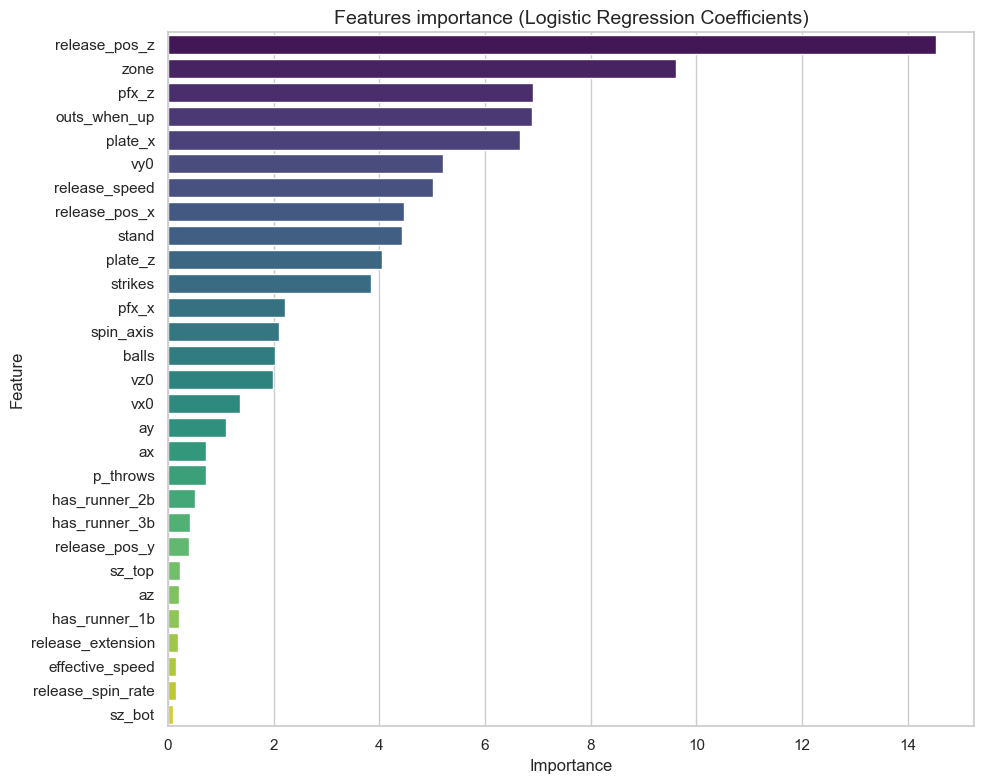

In [90]:
#Take the logistic regression step from the pipeline in order to access the coefficients
logreg = best_rl.named_steps["logreg"]

#Get the coefficients
coefs = logreg.coef_
print(coefs.shape)
# #Calculate the importance of each feature as the mean of the absolute values of the coefficients
# #because we have a lot of coefficients for each class
importance = np.mean(np.abs(coefs), axis=0)

#Plot the feature importance
feat_imp = pd.Series(importance, index=XTrain_mlb.columns).sort_values(ascending=False)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))
ax = sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis', legend=False, hue=feat_imp.index)

plt.title("Features importance (Logistic Regression Coefficients)", fontsize=14)
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

<p style="text-align: center;"><em>Figure 7:  Feature Importance (Logistic Regression)</em></p>


We prefer to show the ones that have more importace 

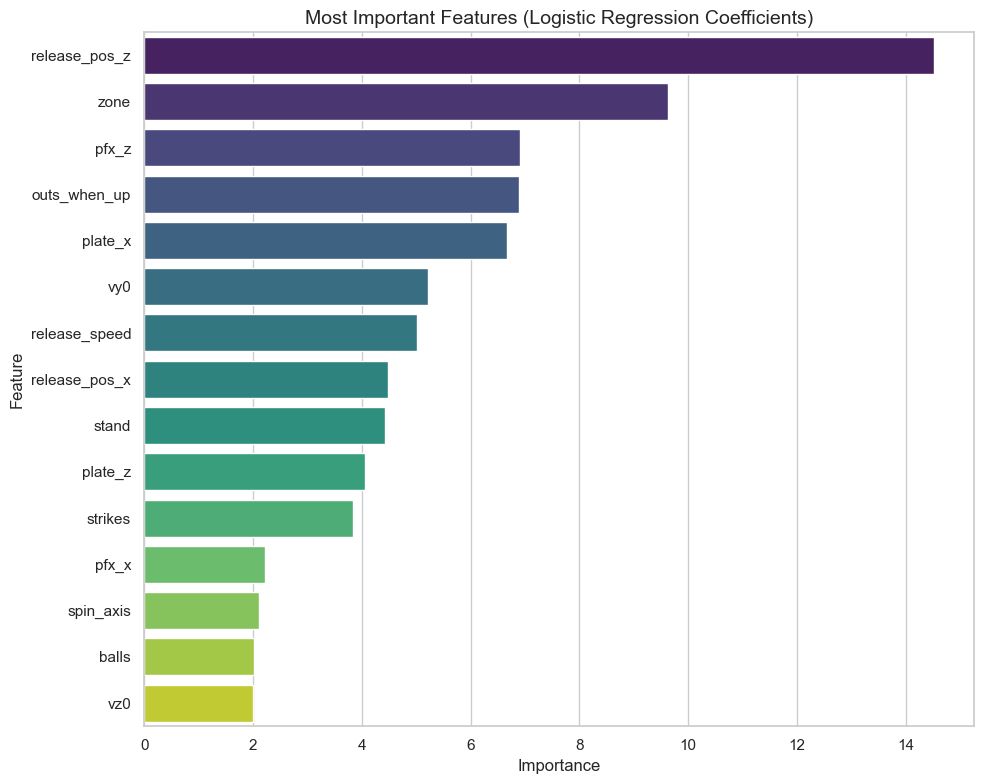

In [91]:
top_n = 15
feat_imp_top = feat_imp.nlargest(top_n)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))
ax = sns.barplot(x=feat_imp_top.values, y=feat_imp_top.index, palette='viridis', legend=False, hue=feat_imp_top.index)

plt.title("Most Important Features (Logistic Regression Coefficients)", fontsize=14)
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

<p style="text-align: center;"><em>Figure 8:  Feature Importance (Logistic Regression)</em></p>



The plot shows that the most influential features (higher magnitude) are the following ones:
- release_pos_z
- zone
- plate_x
- outs_when_up
- release_pos_x
- pfx_z


But the are more   features thar are a bit less importan such as:
- vy0
- release_speed
- strikes
- stand
- pfx_x
- vz0
- spin_axis
- balls

The rest of the feautares are meaningless.

After analysing the ones that are  relenvant we can conclude that these are related with the pitch type, so game context variables such as balls or runners have limited predictive power for pitch type. In conclusion, the model relies on pyshical and mechanical varibles (position,movement or velocity) rather than contextual variables that  could determine the game.


We will now visualize how the f1_macro score varies across different values of C.

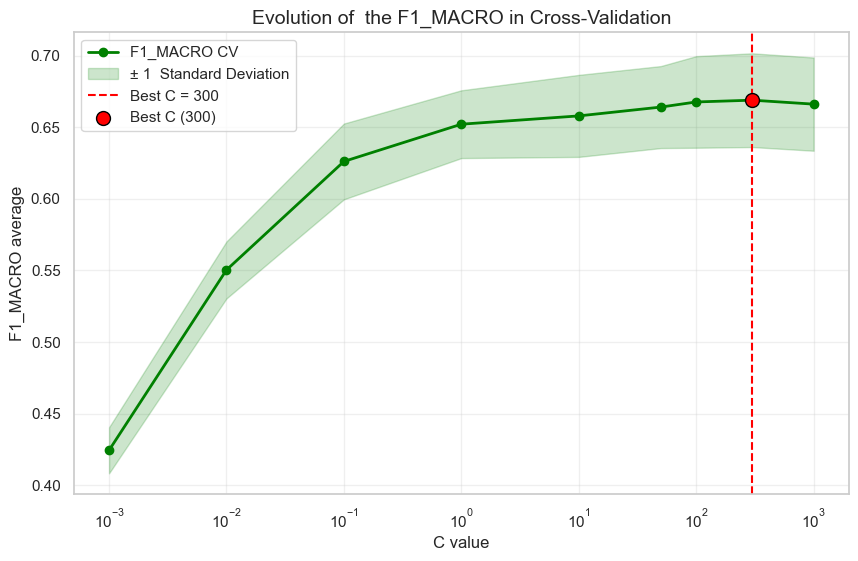

In [92]:
#Extract cross-validation results 
results = grid_rl.cv_results_

#Extract C values on the cross-validation 
C_values = results['param_logreg__C'].data.astype(float)

#Extract mean test scores 
mean_scores = results['mean_test_score']

#Extract standard deviation of test scores
std_scores = results['std_test_score']

# Create a DataFrame to organize and sort
df_plot = pd.DataFrame({'C': C_values,'mean': mean_scores, 'std': std_scores})

#Sort by C
df_plot = df_plot.sort_values(by='C')

# If there are repeated C values, take the average
df_plot = df_plot.groupby('C', as_index=False).mean()

#Plot
sns.set_theme(style="whitegrid")
#Define the size of the figure
plt.figure(figsize=(10,6))
plt.plot(df_plot['C'], df_plot['mean'], marker='o', color='green', linewidth=2, label='F1_MACRO CV')

plt.fill_between(df_plot['C'],   df_plot['mean'] - df_plot['std'], 
                 df_plot['mean'] + df_plot['std'], 
                 color='green', alpha=0.2, label='± 1  Standard Deviation')

#Take the best C value
best_C = grid_rl.best_params_['logreg__C']
best_score = df_plot.loc[df_plot['C'] == best_C, 'mean'].values[0]

#Make a red line to indicate the best C
plt.axvline(x=best_C, color='red', linestyle='--', label=f"Best C = {best_C}")
#Add a red dot to indicate the best C
plt.scatter(best_C, best_score, s=100, color='red', edgecolors='black', zorder=5, label=f'Best C ({best_C})')

#Add title and labels
plt.title("Evolution of  the F1_MACRO in Cross-Validation", fontsize=14)
plt.xlabel("C value", fontsize=12)
plt.ylabel("F1_MACRO average", fontsize=12)

 #See C more clearly
plt.xscale('log') 
plt.grid(True, alpha=0.3)
#Create a legend
plt.legend()

#Show the plot
plt.show()

<p style="text-align: center;"><em>Figure 9:  Evolution of hyperparameters</em></p>


The following graph shows how  the parameter C improve the model's performance when it increases from very small values. When C is low the model can be strongly regularized, resulting in underfitting and a low score. While C increases the F1_macro score gets higher.

Once its values reaches 10, the curve begins to flatteng, indicating that the gain in higher values will result in minimum gains.

The green shaded area represents the standard deviation (±1 STD) across the cross-validation folds. This visualizes the model's stability. A wider band indicates higher variance, meaning the performance fluctuates depending on the data subset. It is worth noting that while the curve rises, the variance (width of the shadow) remains significant, showing that the model retains some instability even at higher scores

We have drawn a red line in the best C value, the one that GridSearchCV has given us. As we said it was 300 and, altough the f1_macro score seems to be similar, maybe with this value we have an effective balance between regularization and  model complexity.

One thing to be mentioned is that with the plot we can conclude that we have to find a balance between with the regularization.


## 4º. Decision Tree

And last but not least, we are going to analyse a decision tree, which maybe could be the best model. As we did in other steps  we will look for the best parameters using the GridSearching, optimizing for f1_macro and employing 10 folds

In [93]:
#Create the pipeline with preprocessing and decision tree classifier
pipe_dt = Pipeline([('preprocess', preprocess), ('dt', DecisionTreeClassifier())])

#Fist of all, we define the parameter grid of the decision tree to be checked with cross-validation
param_grid = {'dt__min_samples_leaf': [1,2,4,8,10], #Minimum samples required to be at a leaf node
              'dt__min_samples_split': [2,5,10, 20], #Minimum samples required to split an internal node
              'dt__max_depth':[2,5], #Maximum depth of the tree
              'dt__criterion':['entropy','gini'], #Function to measure the quality of a split
              'dt__max_features': [None, 'sqrt', 'log2'], #Number of features to consider when looking for the best split
              'dt__ccp_alpha': [0, 0.0005, 0.001]} #Complexity parameter used for Minimal Cost-Complexity Pruning



#Create the GridSearchCV object from the  decision tree model and the parameter grid
# with 10-fold cross-validation, scoring by f1_macro and n_jobs=-1 to use all processors so 
# the grid search can be faster
clftree = GridSearchCV(estimator=pipe_dt, param_grid=param_grid, cv=10, scoring='f1_macro',n_jobs=-1)

# Fit the GridSearchCV object on the training set to find the best hyperparameters
clftree.fit(XTrain_mlb , yTrain_mlb)

#Print the best parameters and the best score
print("Best parameters founded:", clftree.best_params_)
print("Best CV punctuation:", clftree.best_score_)

#We want to extract the scores of the 10 cross-validations of the best model founded
#so we convert the cv resutls to a Dataframe a we select the row corresponding to the best parameters

#Convert the cv resutols to a Dataframe
results = pd.DataFrame(clftree.cv_results_)

#Select the row corresponding to the best model
best_row = results[results["rank_test_score"] == 1].iloc[0]

#There are a lot of columns, but we select only the ones corresponding to the cross-validation scores
cv_scores = best_row[[f"split{i}_test_score" for i in range(10)]]

#Print the  scores
print("Scores of the 10 cross-validations of the best model:")
print(cv_scores.values.astype(float)) #We use astype so when we print it out it only print the numbers



    


Best parameters founded: {'dt__ccp_alpha': 0.0005, 'dt__criterion': 'entropy', 'dt__max_depth': 5, 'dt__max_features': None, 'dt__min_samples_leaf': 4, 'dt__min_samples_split': 2}
Best CV punctuation: 0.6178077022335953
Scores of the 10 cross-validations of the best model:
[0.63358155 0.57613776 0.57676314 0.60823783 0.63085013 0.63328731
 0.64743593 0.62867788 0.64379326 0.59931224]


We have printed three things:

1. Best parameters founded: in our case the best combination of parameters that achieved the highest average performance during cross-validation  are ccp_alpha=0.0005, criterion='entropy', based on the information theroy, max_depth = '5',max_features=None, it uses all the feautres,min_samples_leaf=4 and  min_samples_split='5'.
2. Best CV punctuation: the best model  achieve an average f1-macro score of 0.617.

3. Scores of the 10 cross-validations of the best model:  the range of the individual fold scores goes from T from 0.57 to 0.65, showing moderate variability across folds.

Once we had the best model, we save it.

In [94]:
#Save the best decision tree model
best_dt=clftree.best_estimator_

#Show the best decision tree model
best_dt

,steps,"[('preprocess', ...), ('dt', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


The decision tree the importance of each variable is based on how much it contributes to reducing impurity. 

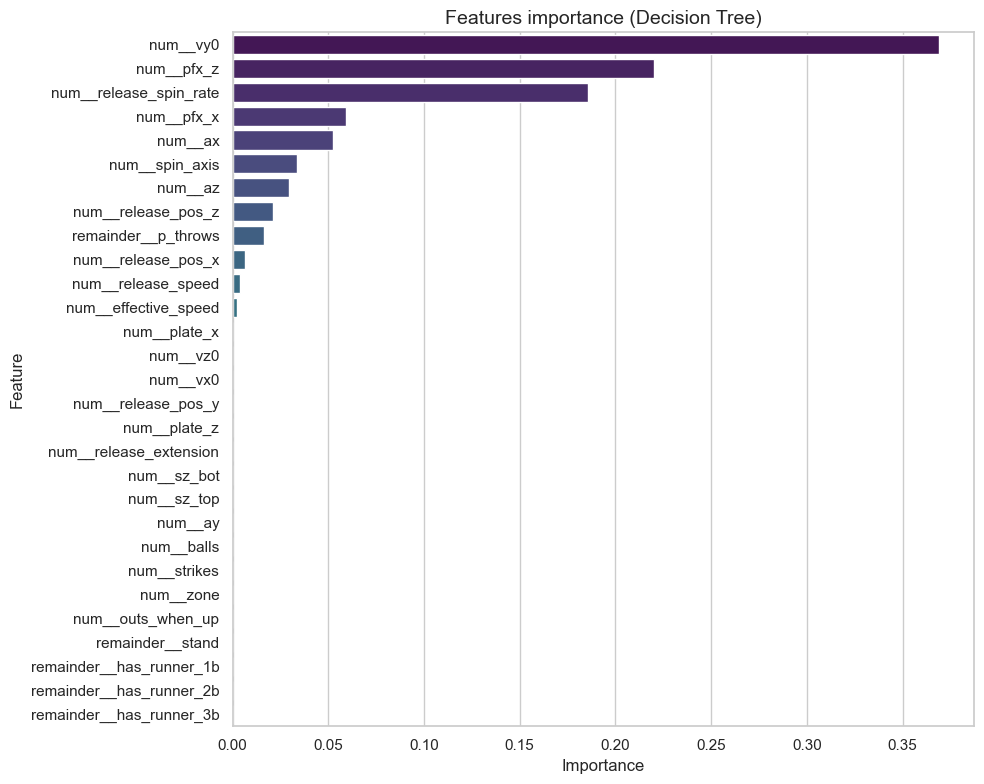

In [95]:
#Obtain the decision tree from the pipeline
best_tree = best_dt.named_steps['dt']

#Obtaingn feature names after preprocessing
feature_names = best_dt.named_steps['preprocess'].get_feature_names_out()

#Get feature importances from the decision tree
importances = best_tree.feature_importances_

#Create ordered series to visualize feature importances based on importance values
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))
ax = sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis', legend=False, hue=feat_imp.index)

plt.title("Features importance (Decision Tree)", fontsize=14)
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


<p style="text-align: center;"><em>Figure 10:  Feature importance (Decision Tree)</em></p>


We limit the plot so we can  have a better graph

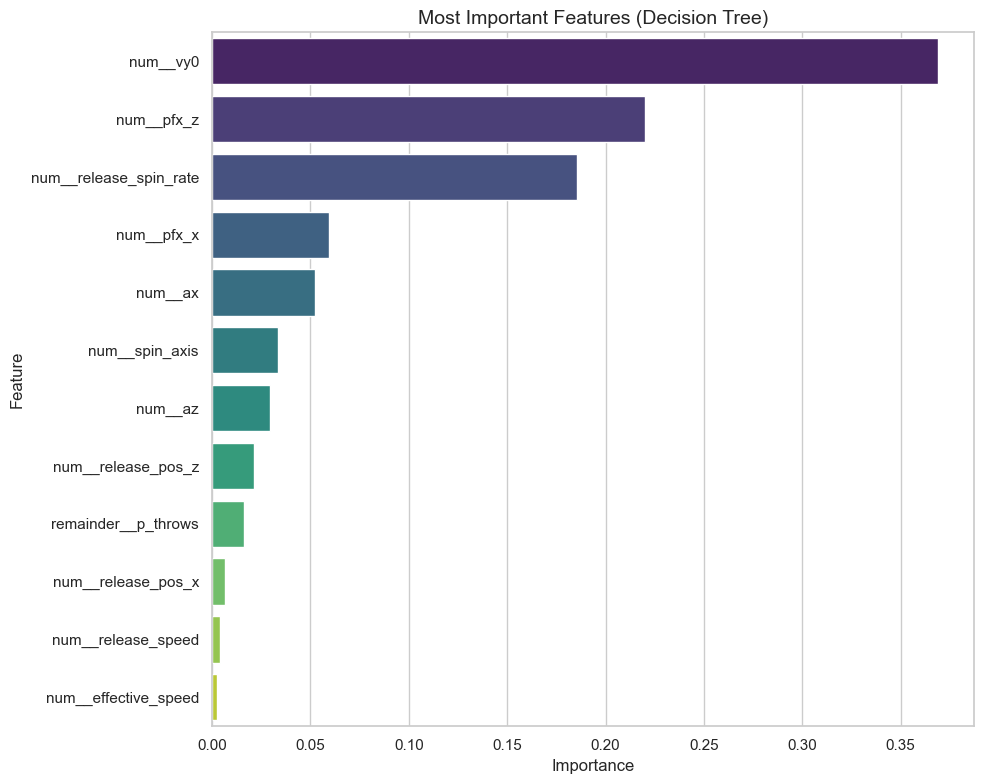

In [96]:
limit = 12
feat_imp_top = feat_imp.nlargest(limit)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))
ax = sns.barplot(x=feat_imp_top.values, y=feat_imp_top.index, palette='viridis', legend=False, hue=feat_imp_top.index)

plt.title("Most Important Features (Decision Tree)", fontsize=14)
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

<p style="text-align: center;"><em>Figure 11: Most important features (Decision Tree)</em></p>


This graph allows us to understand which features the tree relies on most when separating the different pitch types. By examining these importances, we can identify that the tree only relies on a small set of variables.The most influential feature by far es vy0 (initial velocity in y direction), which hast 35% of importance.Secondly, we have pfx_z (vertical break of the pitch) and release_spin_rate with 25% and 20%. These three features dominate the model, indicating that the tree  prioritizes velocity, vertical break, and spin characteristics when making decisions.

Then, we have a small group of  variable that have little importance, such as ax, pfx_x, az, release_pos_x, release_pos_z, release_speed and effective_speed

In contrast, many contextual variables—such  have almost zero importance which means that out model  ignores the tactical or situational context and focuses  exclusively on the physical properties of the pitch. This can be  expected as we said earlier, because  pitch type is almost determined by mechanics rather than game situation.

Compared to logistic regression, which distributes influence more smoothly across many features, the tree shows  a reliance on a small group of variables.

Finally, we are going to observe the structure of the final tree

In [97]:
#Make a text representation of the decision tree
tree_text = export_text(best_tree, feature_names=list(feature_names), show_weights=False)

#Get the labels names of the targer variable so we can use them 
label_names = sorted(mlb_df['pitch_type'].unique())

#Replace class numbers with actual pitch type names
#  for better readability
for i, name in enumerate(label_names):
    tree_text = tree_text.replace(f"class: {i}", f"class: {name}")

#Print the text representation of the decision tree
print(tree_text)


|--- num__vy0 <= -0.07
|   |--- num__pfx_z <= 0.57
|   |   |--- num__release_spin_rate <= -0.93
|   |   |   |--- num__release_pos_x <= -1.04
|   |   |   |   |--- class: CH
|   |   |   |--- num__release_pos_x >  -1.04
|   |   |   |   |--- num__spin_axis <= 0.53
|   |   |   |   |   |--- class: CH
|   |   |   |   |--- num__spin_axis >  0.53
|   |   |   |   |   |--- class: FS
|   |   |--- num__release_spin_rate >  -0.93
|   |   |   |--- num__pfx_x <= -0.95
|   |   |   |   |--- num__pfx_x <= -1.31
|   |   |   |   |   |--- class: SI
|   |   |   |   |--- num__pfx_x >  -1.31
|   |   |   |   |   |--- class: SI
|   |   |   |--- num__pfx_x >  -0.95
|   |   |   |   |--- num__ax <= 0.99
|   |   |   |   |   |--- class: FC
|   |   |   |   |--- num__ax >  0.99
|   |   |   |   |   |--- class: SI
|   |--- num__pfx_z >  0.57
|   |   |--- num__pfx_x <= -1.04
|   |   |   |--- num__release_pos_x <= -0.67
|   |   |   |   |--- num__ax <= -1.42
|   |   |   |   |   |--- class: FF
|   |   |   |   |--- num__ax > 

We have printed a text version of the tree, but it isn't interpretable so we are going to use a function given by the teache so we can properly  see the tree

Tree depth: 5
Number of leaves: 31


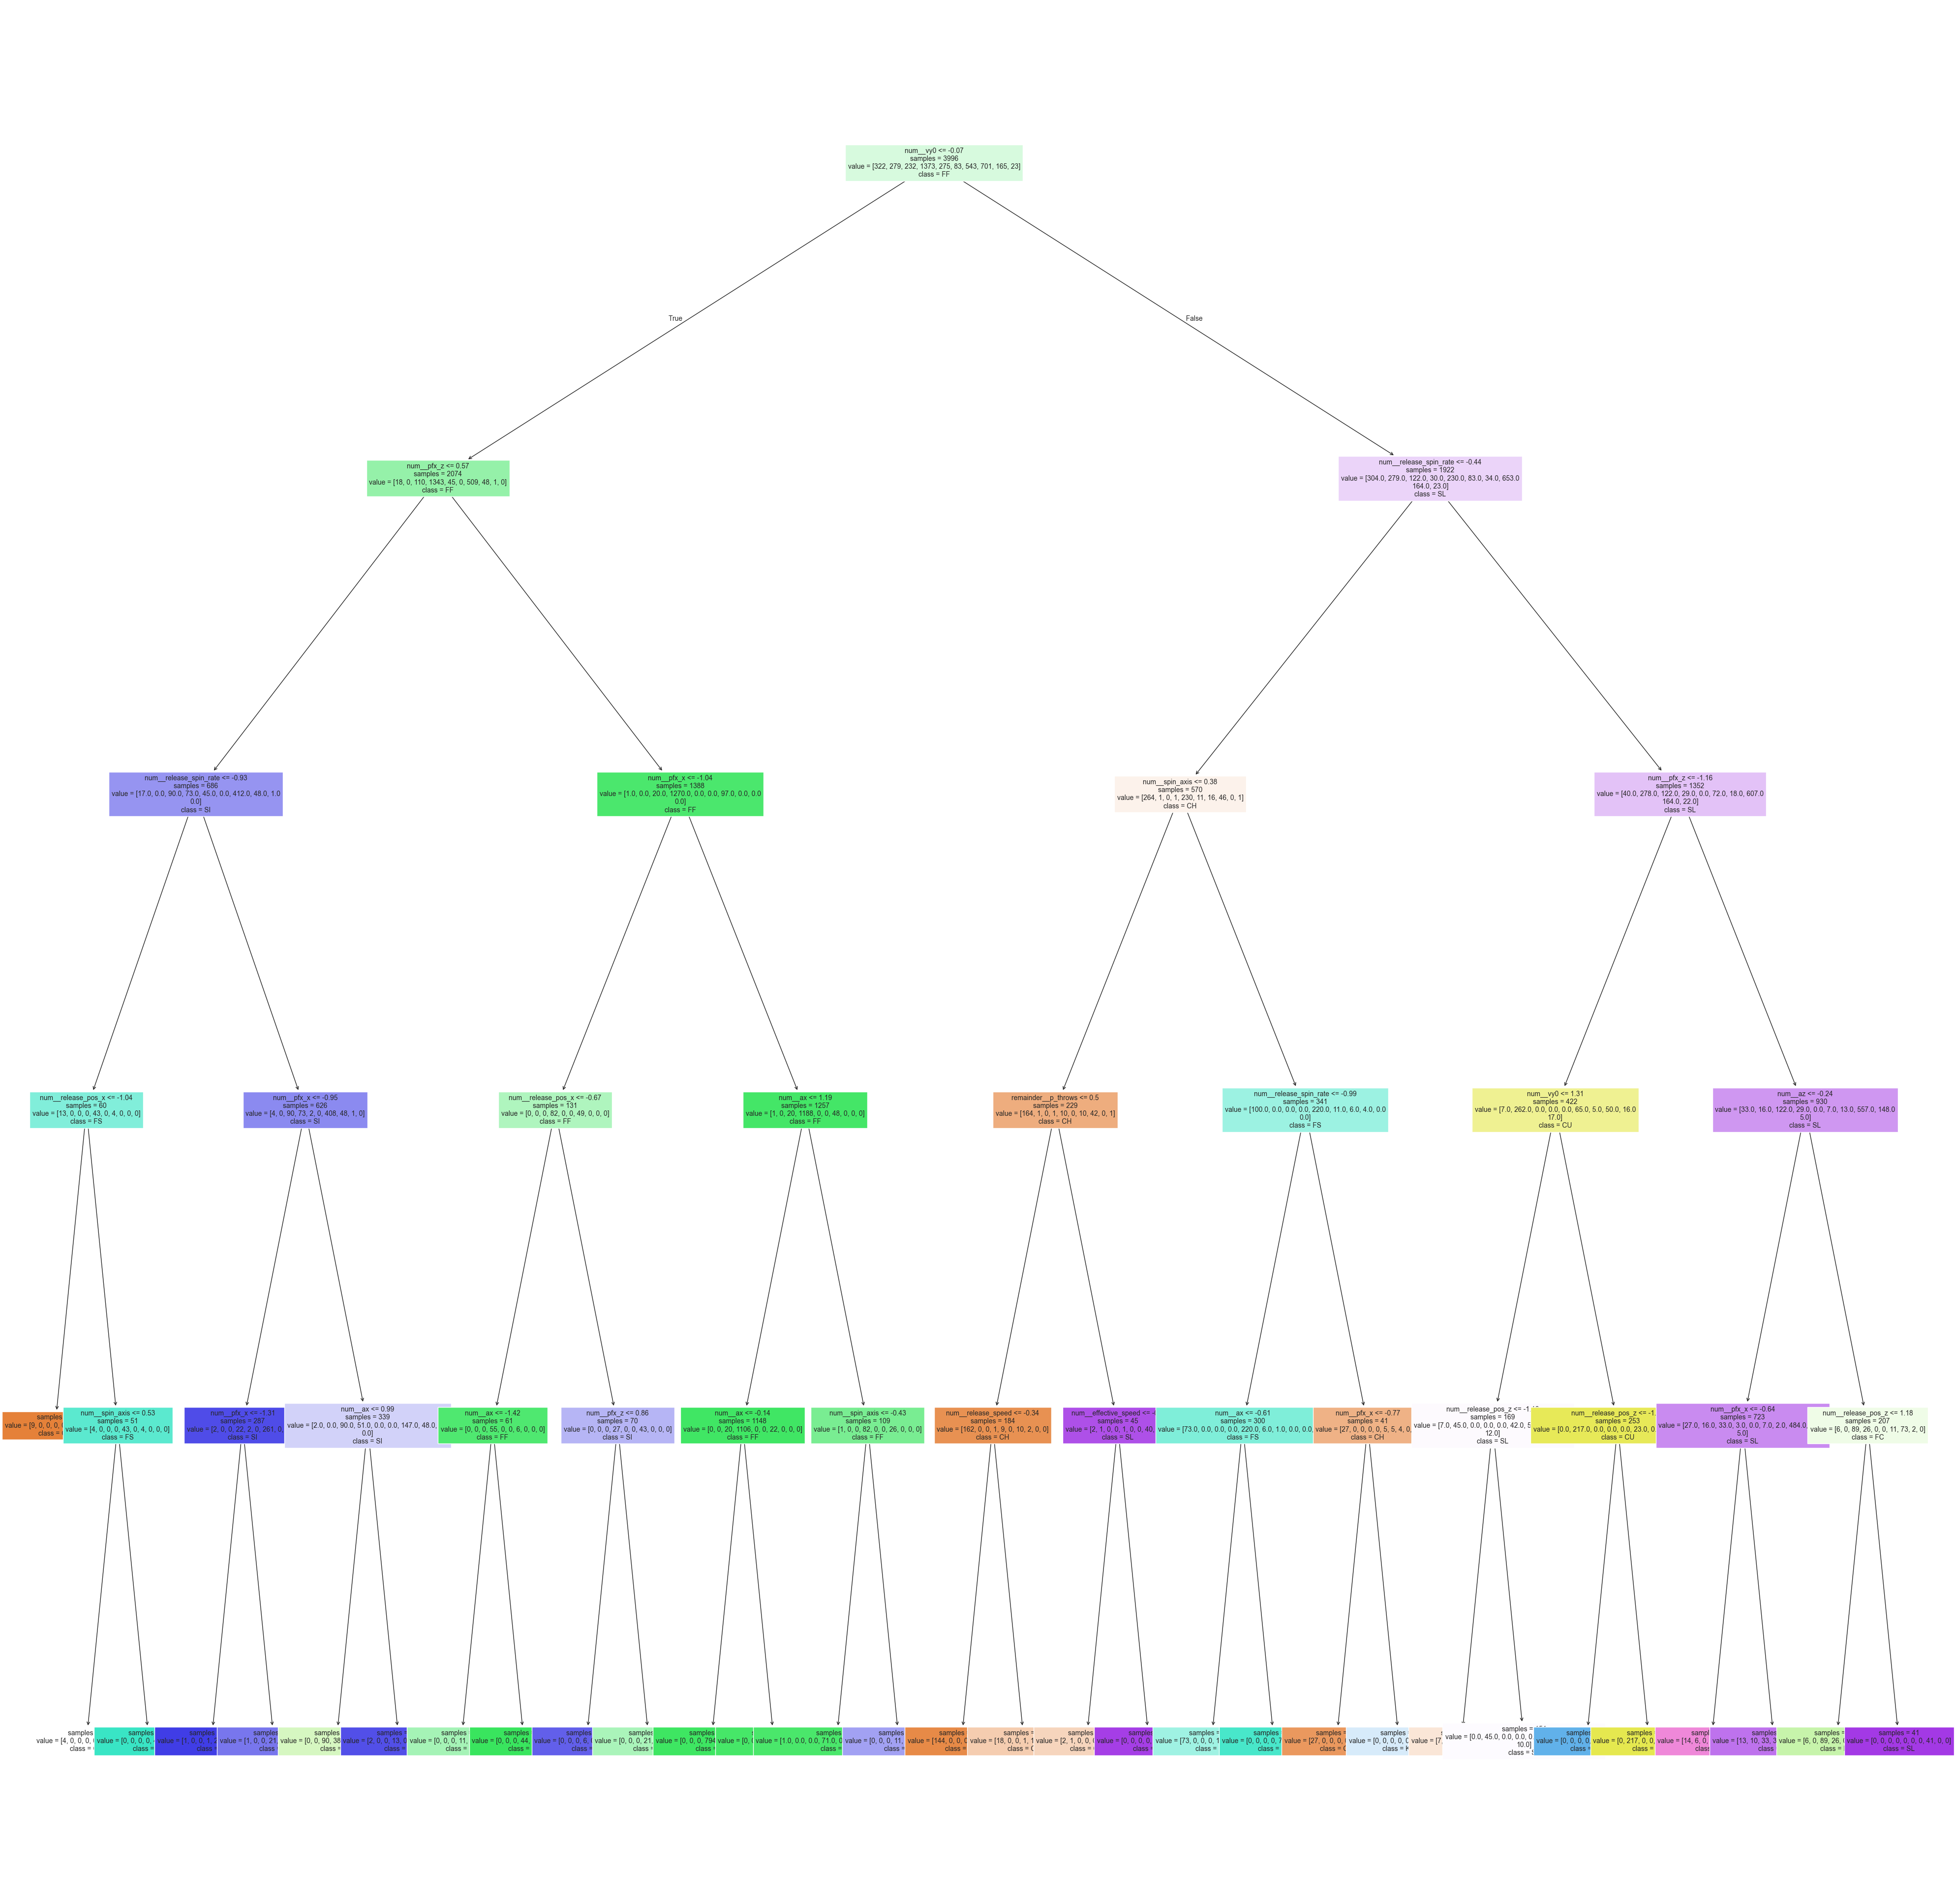

In [98]:

#Stablish the size of the figure
plt.subplots(figsize=(50, 50))

#Print the depth and number of leaves of the tree
print(f"Tree depth: {best_tree.get_depth()}")
print(f"Number of leaves: {best_tree.get_n_leaves()}")

#Plot the decision tree
plot = plot_tree(decision_tree = best_tree,feature_names = feature_names,
            class_names = label_names,filled = True,
            impurity= False, fontsize = 10,
            precision = 2,
       )

<p style="text-align: center;"><em>Figure 12:  Tree structure</em></p>


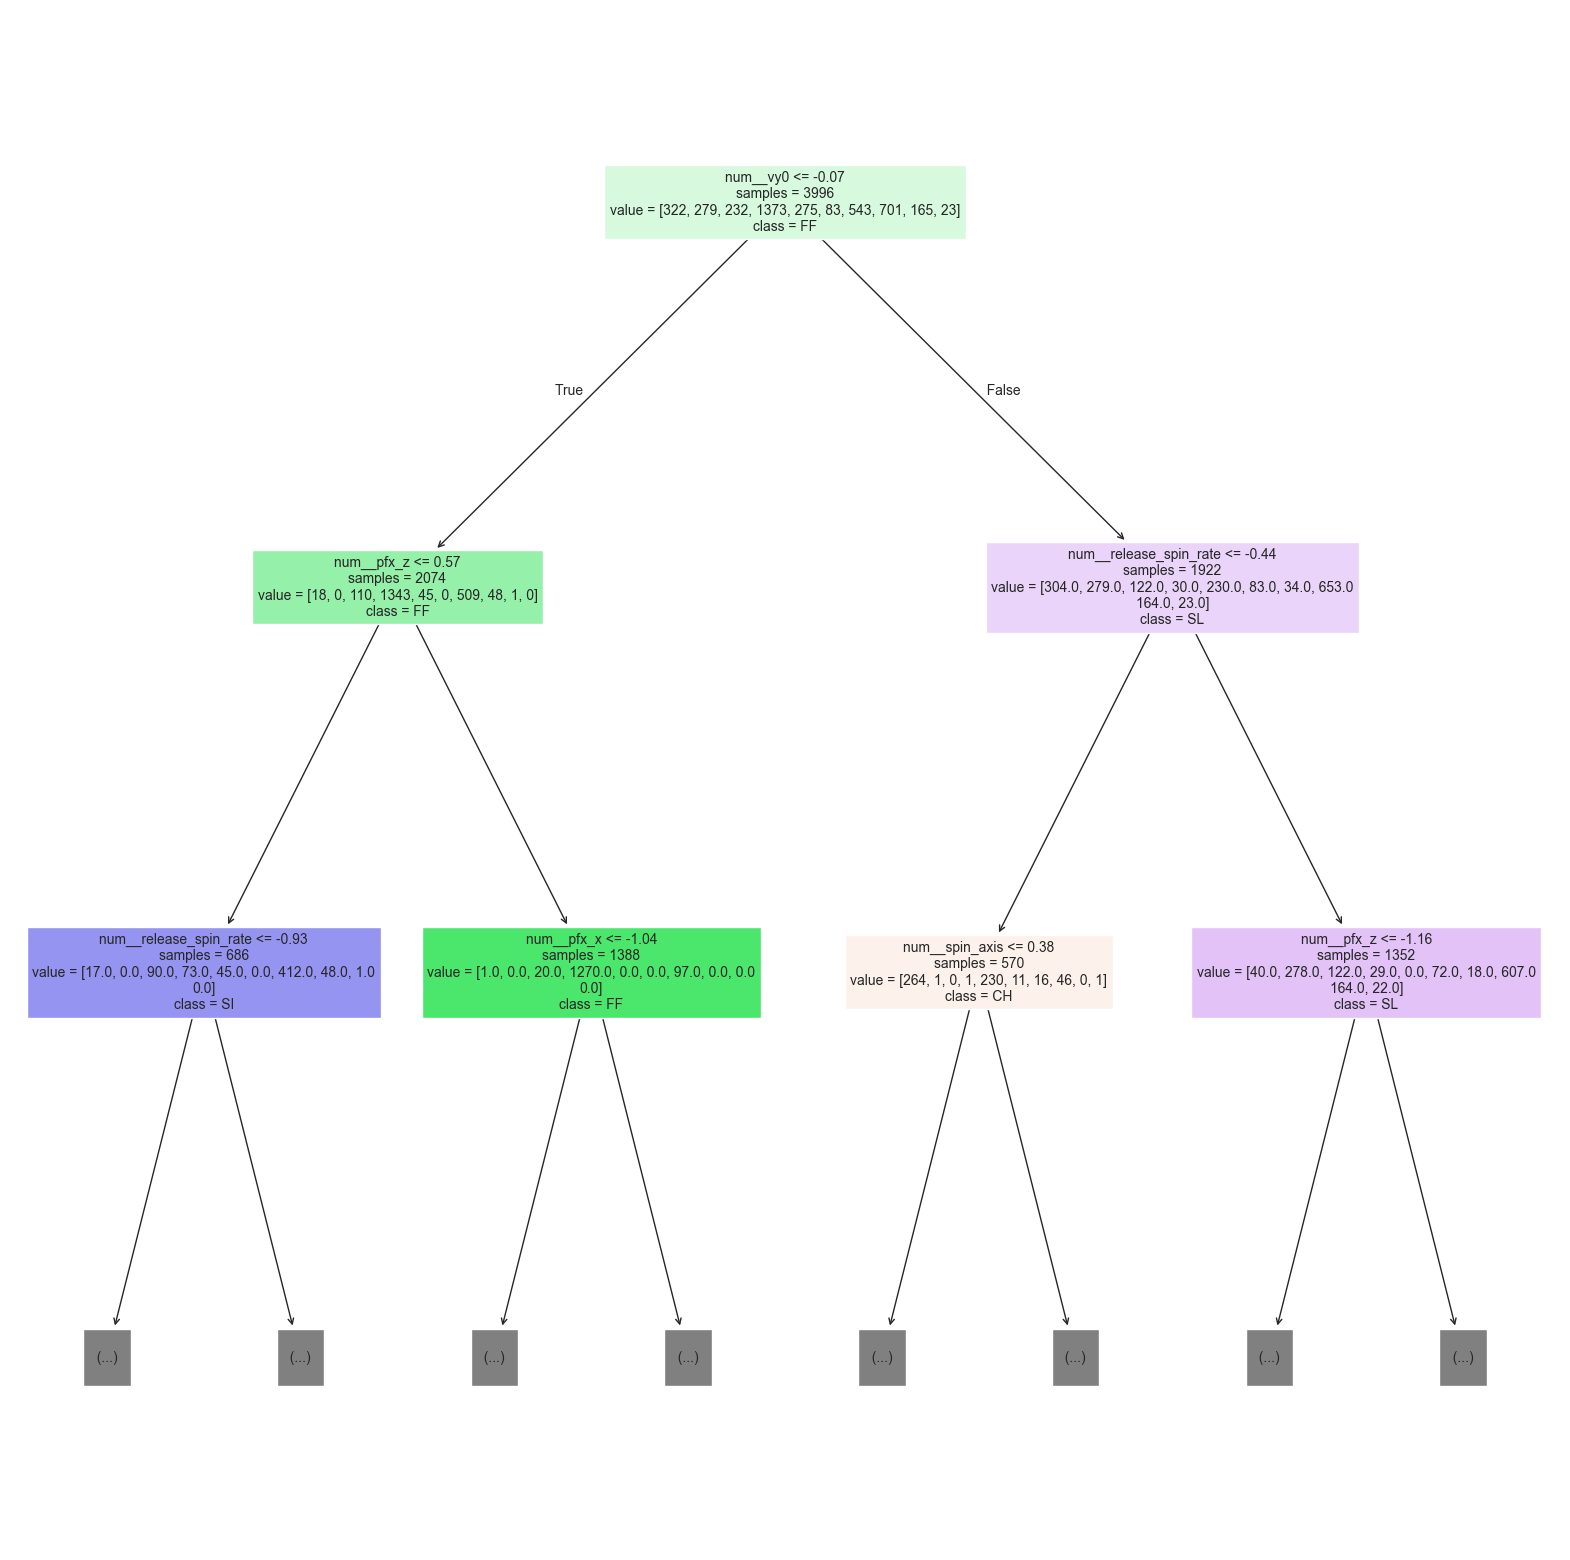

In [99]:
plt.subplots(figsize=(20, 20))
plot = plot_tree(decision_tree = best_tree,feature_names = feature_names,
            class_names = label_names,filled = True,
            impurity= False, fontsize = 10,
            precision = 2,max_depth=2
       )

<p style="text-align: center;"><em>Figure 13:  Tree structure of the three first levels</em></p>


- Level 1: The first split is performed based on the highest-weighted variable, vy0 (initial velocity towards home plate). This divides the data into fast pitches and slow pitches, as pitches that are not as straight typically have lower velocities. This split creates two distinct branches at the second level.

    -  Level 2 - Fast pitches: In this branch, the splitting rule is based on pfx_z (the second most important variable), which indicates how much the pitch deviates vertically compared to a spin-free trajectory. Some pitches, like the FF (Four-Seam Fastball), tend not to drop as much ("ride"), whereas others do, such as the SI (Sinker) or FC (Cutter). Once again, this division generates two further subdivisions.

        
        -   Level 3 - Pitches with greater drop: In this branch of fast pitches with significant drop, the Sinker (SI) is the dominant pitch. The model attempts to refine this group using release_spin_rate (rotation off the pitcher's hand), which is typically lower for Sinkers.

        -  Level 3 - Pitches with less drop: Among the straighter, faster pitches with minimal vertical drop, the majority are FF (Four-Seam Fastballs). Similar to the previous case, the model attempts to refine this group, but here it uses pfx_x (horizontal movement).

    - Level 2 - Slow pitches: In the slow pitch branch, the next factor considered is release_spin_rate (rotation upon release, as previously defined). This allows for the separation of off-speed pitches (e.g., Changeups/CH) from breaking balls (e.g., Curveballs/CU).

       -  Level 3 - Pitches with lower spin: In the category of slow, low-spin pitches, the Changeup (CH) is the dominant pitch. Consequently, the model examines spin_axis (axis of rotation) to confirm the ball follows the typical movement pattern for this pitch type.

        - Level 3 - Pitches with higher spin: For these pitches, the model now looks at pfx_z (vertical deviation from a spin-free trajectory) to determine if the ball drops significantly—typical of pitches like the CU (Curveball)—or drops less, which is typical of the SL (Slider).

# Best Model

Once the analysis of all models is completed, it is time to choose the best one. To do this, we will generate a table to support our decision.

Below is a summary chart showing the macro F1 score obtained for the different models tested in Cross-Validation.






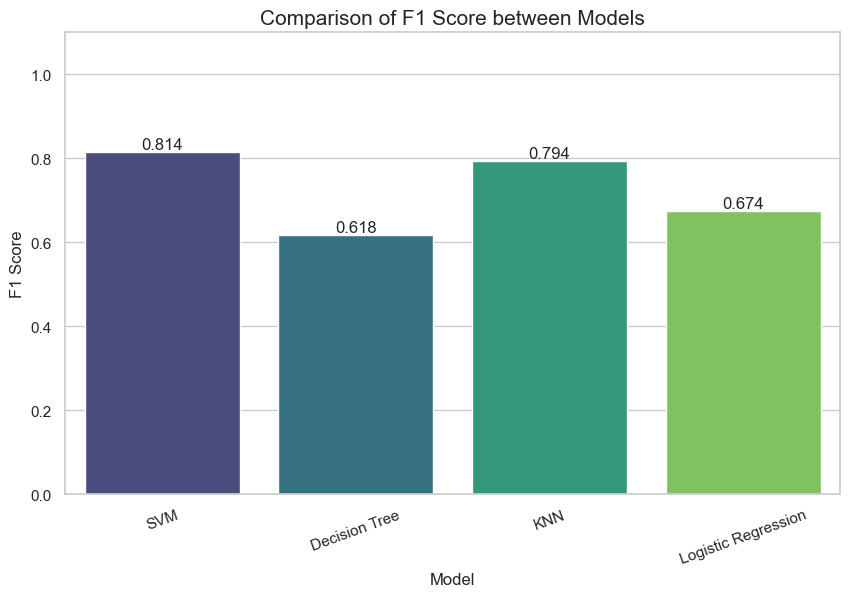

In [100]:
#Compare the F1 scores of the different models
f1_scores = {
    'SVM': grid_svm.best_score_,
    'Decision Tree': clftree.best_score_,
    'KNN': grid_knn.best_score_,
    'Logistic Regression': grid_rl.best_score_,
}

df_f1 = pd.DataFrame(list(f1_scores.items()), columns=['Model', 'F1 Score'])

# Plot the F1 scores
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(x='Model', y='F1 Score', data=df_f1, palette='viridis', legend=False,hue='Model')

#Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

#Adjustments
plt.title("Comparison of F1 Score between Models", fontsize=15)
plt.ylim(0, 1.1)
plt.xticks(rotation=20)
plt.show()




Based on these results, we observe that the model achieving the best performance in cross-validation is SVM, with a macro F1 superior to the rest of the techniques. It is important to highlight that these values correspond to the best models found after optimizing their hyperparameters. Therefore, we select SVM as the final 
model.

In [101]:
#Make predictions on the test data using the best SVM model
yPred_svm = best_svm.predict(XTest_mlb)
acc=accuracy_score(yTest_mlb, yPred_svm)
pr_sc=precision_score(yTest_mlb, yPred_svm, average='macro', zero_division=0)
re_sc=recall_score(yTest_mlb, yPred_svm, average='macro', zero_division=0)
f1_sc=f1_score(yTest_mlb, yPred_svm, average='macro', zero_division=0)
#Print the accuracy obtained by the best SVM model for the test data
print("Test Accuracy:", acc)
print("Test Precision (macro):", pr_sc)
#Print the recall macro obtained by the best SVM model for the test data
print("Test Recall (macro):", re_sc)
#Print the f1 score macro obtained by the best SVM model for the test data
print("Test F1 Score (macro):", f1_sc)
#Print the clasification report for the best SVM model and the test data
print("\nClassification report:\n")
print(classification_report(yTest_mlb, yPred_svm, zero_division=0))

Test Accuracy: 0.8798798798798799
Test Precision (macro): 0.8497410533780243
Test Recall (macro): 0.7488412616434689
Test F1 Score (macro): 0.7672621953975651

Classification report:

              precision    recall  f1-score   support

          CH       0.83      0.76      0.79        75
          CU       0.92      0.96      0.94        75
          FC       0.81      0.69      0.75        62
          FF       0.94      0.97      0.96       342
          FS       0.76      0.84      0.80        70
          KC       0.74      0.56      0.64        25
          SI       0.93      0.88      0.90       143
          SL       0.84      0.90      0.87       168
          ST       0.74      0.76      0.75        33
          SV       1.00      0.17      0.29         6

    accuracy                           0.88       999
   macro avg       0.85      0.75      0.77       999
weighted avg       0.88      0.88      0.88       999



This seems a bit simple so we decide to make two graps so we be could be able to understand what is happening

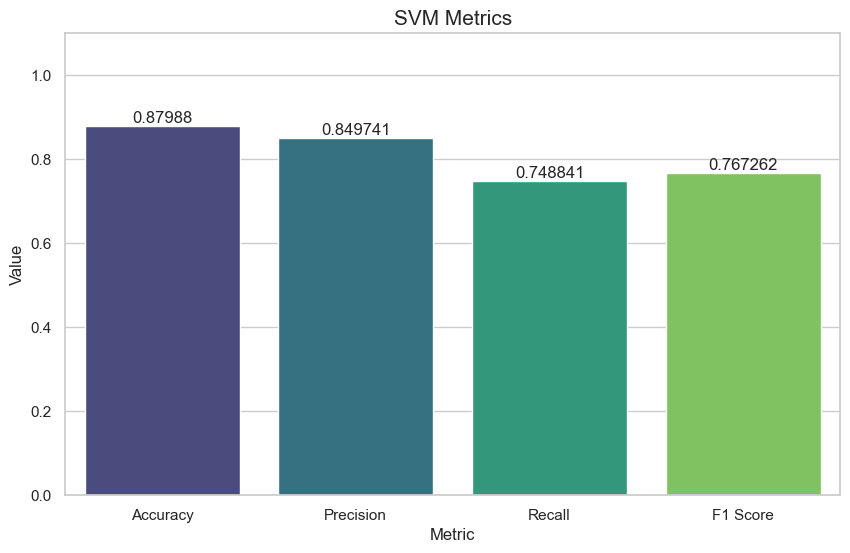

In [102]:

metrics_data = { 'Accuracy': acc,'Precision': pr_sc, 'Recall': re_sc, 'F1 Score': f1_sc }

df_metrics = pd.DataFrame(list(metrics_data.items()), columns=['Metric', 'Value'])

#Plot the metrics in a bar chart
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(x='Metric', y='Value', data=df_metrics, palette='viridis', legend=False,hue='Metric')
# Give value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container)
#TItle and limits
plt.title("SVM Metrics", fontsize=15)
plt.ylim(0, 1.1)  
plt.show()

<p style="text-align: center;"><em>Figure 14:  SVM metrics (SVM)</em></p>


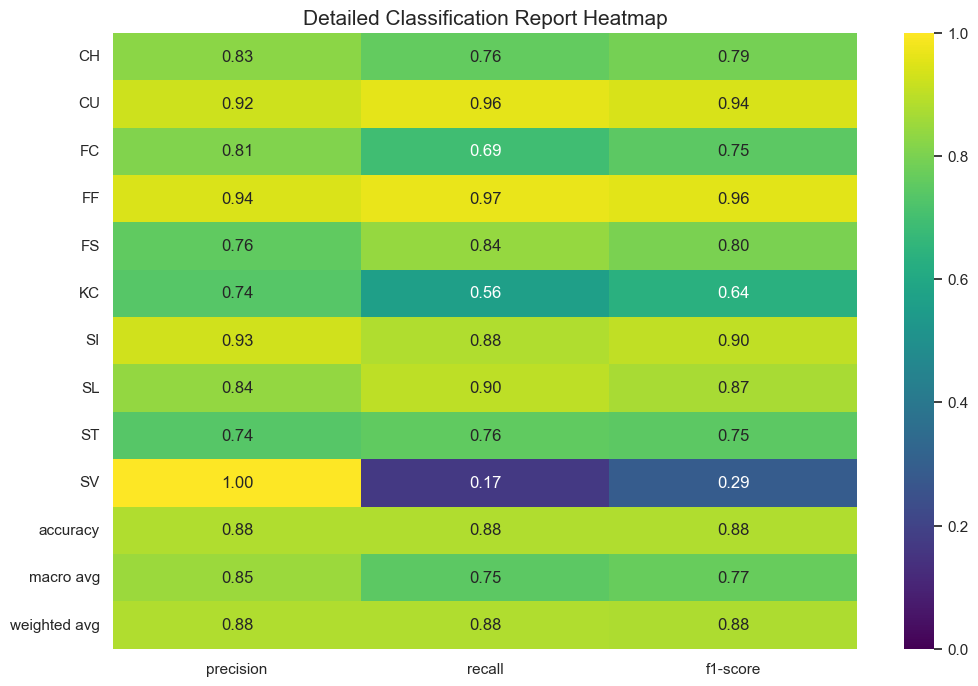

In [103]:
#Save the classification report 
report_dict = classification_report(yTest_mlb, yPred_svm, zero_division=0, output_dict=True)

df_report = pd.DataFrame(report_dict).transpose()

#Eliminate the support column for better visualization
df_plot = df_report.drop(columns=['support'])

plt.figure(figsize=(12, 8))
sns.heatmap(df_plot, annot=True, cmap='viridis', fmt='.2f', vmin=0, vmax=1)

plt.title("Detailed Classification Report Heatmap", fontsize=15)
plt.show()

<p style="text-align: center;"><em>Figure 15:  Report Heatmap (SVM)</em></p>


The previous output shows the evaluation metrics and the clasification report obtained by the best model on the test data:

- Accuracy: 0.87987. Indicates that approximately 87% of the test samples are correctly classified.
- Macro Precision: 0.84974. Represents the unweighted average of the precision values across all classes.
- Macro Recall: 0.74884. Represents the unweighted average of the recall values across all classes.
- Macro f1 score: 0.76726. Corresponds to the average F1-score computed across all classes.

In the classification report, it can be observed that classes with larger support (i.e., a higher number of samples) tend to obtain better performance metrics than classes with very small support.
For example, class SV, with only 6 samples, shows low performance values (recall = 0.17, f1 = 0.29).
In contrast, class FF, with 342 samples, achieves much higher scores (recall = 0.97, f1 = 0.96).

Create a confusion matrix and a heatmap to undestand the number of correct and incorrect predictions that our best SVM model produce.


>>> Confusion Matrix (SVM):

Predicción  CH  CU  FC   FF  FS  KC   SI   SL  ST  SV
Real →                                               
CH          57   0   0    0  17   0    1    0   0   0
CU           0  72   0    0   0   3    0    0   0   0
FC           0   0  43    6   0   0    1   12   0   0
FF           0   0   3  331   0   0    8    0   0   0
FS          11   0   0    0  59   0    0    0   0   0
KC           0   2   0    0   0  14    0    9   0   0
SI           1   0   0   14   2   0  126    0   0   0
SL           0   2   7    0   0   1    0  151   7   0
ST           0   2   0    0   0   0    0    6  25   0
SV           0   0   0    0   0   1    0    2   2   1


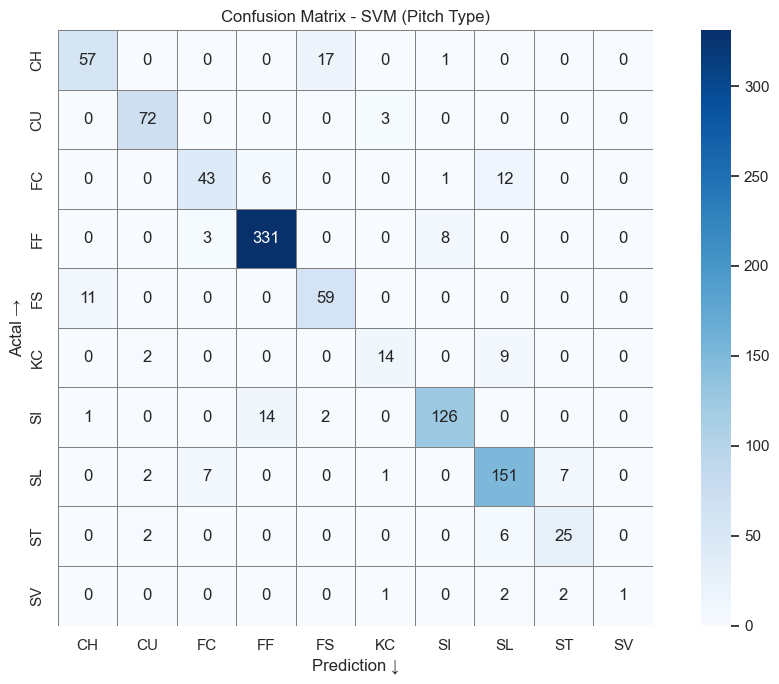

In [104]:
#Obtain a list with the class names
label_names = sorted(mlb_df['pitch_type'].unique())

#Make the confusion matrix using the true and predicted labels
cm = confusion_matrix(yTest_mlb, yPred_svm, labels=label_names)

#Convert the confusion matrix into a DataFrame for easier reading
cm_df = pd.DataFrame(cm, index=label_names, columns=label_names)

#Rename the axes to show what each direction represents
cm_df.index.name = "Real →"
cm_df.columns.name = "Predicción"

#Print the confusion matrix in text format
print("\n>>> Confusion Matrix (SVM):\n")
print(cm_df.to_string())

#Plot the heatmap, which shows the confusion matrix in a visual format
plt.figure(figsize=(10, 7))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=True,
            square=True, linewidths=.5, linecolor='gray')

plt.title("Confusion Matrix - SVM (Pitch Type)")
plt.ylabel("Actal →")
plt.xlabel("Prediction ↓")
plt.tight_layout()
plt.show()




<p style="text-align: center;"><em>Figure 16:  Confusion Matriz (SVM)</em></p>


The text-based output shows the confusion matrix obtained with the SVM model, where rows correspond to the true classes and columns correspond to the predicted classes. As in the classification report, classes with a larger number of observations tend to achieve better results, meaning the model correctly identifies more samples from these categories. For example, class FF shows a high number of correct predictions, while classes with fewer samples, such as SV, present more classification errors. The second figure displays the same information in a visual format through a heatmap, which makes the distribution of correct and incorrect predictions easier to interpret. It can also be observed that for classes with fewer samples, the test results obtained with the SVM model are worse than those achieved by KNN.

# Conclusion

Finished this work, we have learned the meaning and importance of many of the hyperparameters used in the different models, as well as how tuning them can influence final performance. We were also able to rule out techniques such as SMOTE based on an understanding of its operation and the specific characteristics of our dataset. This is particularly valuable, as it is not always appropriate to automatically apply everything covered in class.

Another significant lesson has been understanding the professional workflow of a machine learning project. Notable aspects include the correct application of scaling without causing data leakage, and the integration of the entire process into a pipeline within each Cross-Validation fold. This has allowed us to work following reproducible best practices, similar to those employed in real-world environments.

Regarding potential improvements, we would like to mention the availability of a larger amount of data for the less frequent classes, as this would enable the models to learn the  structures in greater depth. Another improvement we would like to explore is the application of other types of more complex models, which might better suit our data given its complex structure.